In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings, yaml, vcf, pickle, shutil, subprocess
import scipy.optimize

os.chdir("../")

who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
coll_2014 = pd.read_csv("./data_processing/data_utils/coll2014_SNP_scheme.tsv", sep="\t")
freschi_2020 = pd.read_csv("./data_processing/data_utils/freschi2020_SNP_scheme.tsv", sep="\t")
lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

sys.path.append("utils")
from data_utils import *
from analysis_utils import *
from inSilicoMut_utils import *
import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150
import statsmodels.stats.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

from Bio import SeqIO
warnings.filterwarnings("ignore")

data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

#cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_all.csv")

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETH",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETH': 5, 'MXF': 0.5, 'LEV': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}

silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv")

/tmp/ipykernel_14904/2907390262.py:9: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)


# Isolates with MICs that Span the CC: How are they predicted?

In [2]:
drug = 'ETH'
drug_full_name = abbr_drug_dict[drug]

kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))

df_phenos = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))[['ROLLINGDB_ID', 'Coll2014', 'Lineage', 'Binary']]

df = pd.read_csv(os.path.join(results_dir, f"{drug}_lineage_amino_acid", "test_predictions.csv")).query("Span_CC==1")
df['pred_MIC'] = np.exp2(df['y_pred'])

df['pred_binary'] = (df['pred_MIC'] > cc_dict[drug]).astype(int)
print(f"{np.round(df['pred_binary'].mean(), 3)*100}% of {len(df)} isolates are predicted resistant to {drug_full_name}")

df_insilico_pred = pd.read_csv(os.path.join(results_dir, f"{drug}_lineage_amino_acid", 'inSilico_analysis', kwargs['tier1_loci'][0], "test_predictions.csv"))
ref_pred = df_insilico_pred.query("ROLLINGDB_ID=='MT_H37Rv'").pred_MIC.values[0]

# add to the dataframe
df['ref_pred'] = ref_pred
df['fold_change'] = df['pred_MIC'] / df['ref_pred']
df['log_fold_change'] = np.log(df['fold_change'])

8.200000000000001% of 61 isolates are predicted resistant to Ethionamide


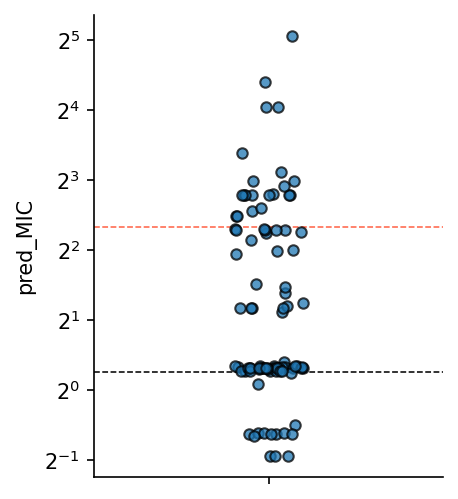

In [77]:
fig, ax = plt.subplots(figsize=(3, 4))

sns.stripplot(data=df,
              y='pred_MIC',
              log_scale=2,
              ax=ax,
              alpha=0.75,
              linewidth=1,
              edgecolor='black'
             )

# sns.histplot(data=df,
#               x='pred_MIC',
#               log_scale=2,
#               ax=ax,
#               alpha=0.75,
#               linewidth=1,
#               edgecolor='black'
#              )

plt.axhline(cc_dict[drug], color='tomato', linestyle='--', linewidth=0.75)
plt.axhline(ref_pred, color='black', linestyle='--', linewidth=0.75)

sns.despine()
plt.show()

# Isolates Predicted with Intermediate MICs: 1 doubling below CC

In [150]:
drug = 'EMB'
drug_full_name = abbr_drug_dict[drug]

kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
df = pd.read_csv(os.path.join(results_dir, f"{drug}_lineage_amino_acid", "test_predictions.csv")).rename(columns={'Isolate': 'ROLLINGDB_ID'})
df['pred_MIC'] = np.exp2(df['y_pred'])

# need to get the reference prediction. Should have saved that in test predictions, but oh well
df_insilico_pred = pd.read_csv(os.path.join(results_dir, f"{drug}_lineage_amino_acid", 'inSilico_analysis', kwargs['tier1_loci'][0], "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'variant'})
ref_pred = df_insilico_pred.query("variant=='MT_H37Rv'").pred_MIC.values[0]

# fix naming
df_insilico_pred['variant'] = df_insilico_pred['variant'].str.replace('_p_', '_p.').str.replace('_c_', '_c.').replace('+', '*')

# add to the dataframe
df['ref_pred'] = ref_pred
df['fold_change'] = df['pred_MIC'] / df['ref_pred']
df['log_fold_change'] = np.log(df['fold_change'])

df_intermediate_MIC = df.query("fold_change >= 0.5 & fold_change <= 1")
print(f"{len(df_intermediate_MIC)} isolates have a predicted MIC ≤ 1 doubling below the CC")

817 isolates have a predicted MIC ≤ 1 doubling below the CC


In [158]:
df_intermediate_MIC_variants = df_intermediate_MIC.merge(isolate_variants.query("drug==@drug_full_name"), on='ROLLINGDB_ID', how='left')

# get the most common variants that are not Group 1-2 variants for that drug
common_new_variants = pd.DataFrame(df_intermediate_MIC_variants.query("~confidence.str.contains('Assoc w R')")[['variant', 'confidence', 'ref_pred', 'fold_change', 'log_fold_change']].value_counts()).reset_index()

common_new_variants = common_new_variants.merge(df_insilico_pred, how='left')

In [166]:
common_new_variants.sort_values("pred_MIC", ascending=False)

,variant,confidence,ref_pred,fold_change,log_fold_change,count,log2_pred_MIC,pred_MIC
1427,embA_p.Pro1082Leu,3) Uncertain significance,1.246963,0.991055,-0.008985,1,0.529141,1.443070
251,embA_p.Gly884Asp,3) Uncertain significance,1.246963,0.812725,-0.207362,2,0.413709,1.332106
868,embA_c.1899G>A,4) Not assoc w R - Interim,1.246963,0.763833,-0.269406,1,0.400980,1.320405
1254,embB_p.Pro731Leu,3) Uncertain significance,1.246963,0.968202,-0.032315,1,0.380275,1.301590
261,embB_p.Pro731Leu,3) Uncertain significance,1.246963,0.972892,-0.027482,2,0.380275,1.301590
...,...,...,...,...,...,...,...,...
1197,Rv2752c_p.Leu191Pro,3) Uncertain significance,1.246963,0.996397,-0.003610,1,NaN,NaN
1198,Rv2752c_p.Ile453Thr,3) Uncertain significance,1.246963,0.995435,-0.004575,1,NaN,NaN
1336,Rv2477c_c.1434G>C,4) Not assoc w R - Interim,1.246963,0.654276,-0.424225,1,NaN,NaN
1404,embA_p.Val871dup,3) Uncertain significance,1.246963,0.980662,-0.019527,1,NaN,NaN


# Moxifloxacin and ethionamide: Which Isolates does lineage change predictions for?

In [3]:
def add_addl_data_pred_df(df):

    df["y_pred_exp"] = np.exp2(df["y_pred"])

    df.loc[df["y_pred_exp"] < df["lower"], "error"] = -1
    df.loc[df["y_pred_exp"] > df["upper"], "error"] = 1
    df["error"] = df["error"].fillna(0).astype(int)

    df.loc[df["y_pred_exp"] < df["lower"] / 2, "essential_disagree"] = -1
    df.loc[df["y_pred_exp"] > df["upper"] * 2, "essential_disagree"] = 1
    df["essential_disagree"] = df["essential_disagree"].fillna(0).astype(int)

    return df

In [4]:
drug = 'ETH'
cc = cc_dict[drug]
df_pred = pd.read_csv(os.path.join(results_dir, f"{drug}_amino_acid", "test_predictions.csv"))
df_pred_lineage = pd.read_csv(os.path.join(results_dir, f"{drug}_lineage_amino_acid", "test_predictions.csv"))

df_phenos = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))

In [5]:
df_pred = add_addl_data_pred_df(df_pred)
df_pred_lineage = add_addl_data_pred_df(df_pred_lineage)

df_combined = df_pred[['Isolate', 'y_pred_exp', 'lower', 'upper', 'y_test', 'error', 'essential_disagree']].merge(df_pred_lineage[['Isolate', 'y_pred_exp', 'error', 'essential_disagree']].rename(columns={'y_pred_exp': 'y_pred_exp_lineage', 'error': 'error_lineage', 'essential_disagree': 'essential_disagree_lineage'}), on='Isolate').merge(df_phenos[['ROLLINGDB_ID', 'Coll2014', 'Lineage', 'Binary', f"{drug}_lower_bound", f"{drug}_midpoint", f"{drug}_upper_bound"]].rename(columns={'ROLLINGDB_ID': 'Isolate'}), on='Isolate').dropna(subset='Binary')

df_combined["fold_change"] = df_combined["y_pred_exp_lineage"] / df_combined["y_pred_exp"]
df_combined["log_fold_change"] = np.log(df_combined["fold_change"])

# this is for plotting. Make them range from 1 to infinity so it's easier to understand from th
df_combined.loc[df_combined['y_pred_exp'] > df_combined['y_pred_exp_lineage'], 'fold_change_plot'] = df_combined['y_pred_exp'] / df_combined['y_pred_exp_lineage']
df_combined.loc[df_combined['y_pred_exp_lineage'] > df_combined['y_pred_exp'], 'fold_change_plot'] = df_combined['y_pred_exp_lineage'] / df_combined['y_pred_exp']
assert df_combined.fold_change_plot.min() >= 1

df_combined['log_fold_change_plot'] = np.log(df_combined['fold_change_plot'])
print(len(df_combined))

# don't keep isolates that span the CC
df_discrepant = df_combined.query("(y_pred_exp < @cc & y_pred_exp_lineage > @cc) | (y_pred_exp > @cc & y_pred_exp_lineage < @cc)").dropna(subset='Binary').reset_index(drop=True)

# average matched pairs change. < 1 means lineage reduces MIC
print(df_combined['fold_change'].mean())

2072
0.9790772662081655


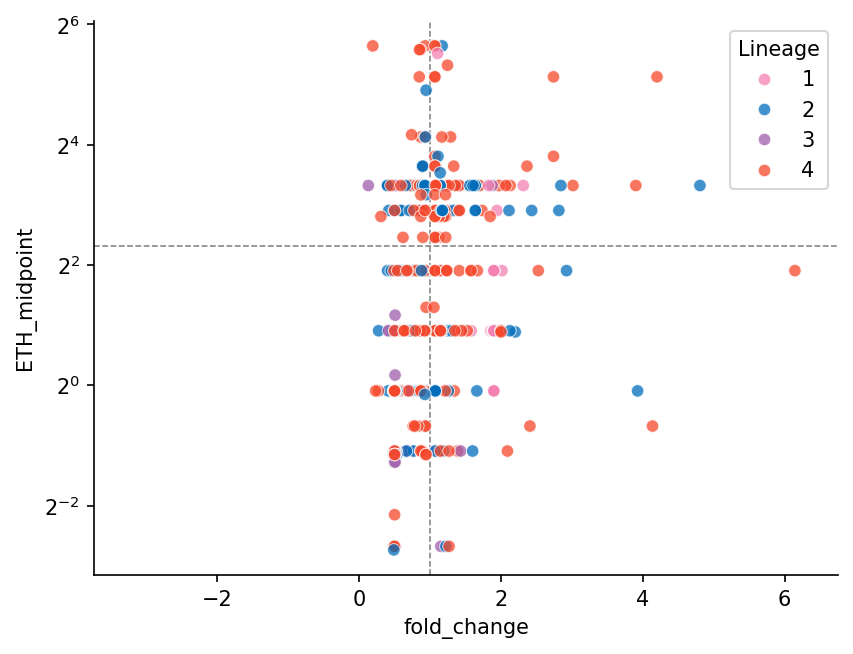

In [6]:
LinToColor_Dict = {"1": "#f381b2",
                   "2": "#006dbb",
                   "3": "#9f5eab",
                   "4": "#f6472b",
                   "5": "#76400e",
                   "6": "#36ba74",
                   "7": "#ffb000",
                   "M.bovis": "gray",
                   "M.canettii": "black",
                   "BOV_AFRI": "gray"
                  }

df_combined['pDST'] = df_combined['Binary'].map({0: 'S', 1: 'R'})

sns.scatterplot(data=df_combined.query("fold_change >= 1.05 | fold_change <= 0.95"),
                x='fold_change',
                y=f'{drug}_midpoint',
                hue='Lineage',
                hue_order=['1', '2', '3', '4'],
                palette=LinToColor_Dict,
                alpha=0.75,
                #style='pDST',
                #style_order=['S', 'R'],
                #markers={'R': 'X', 'S': 'o'}
               )

# both natural numbers (because MICs), so don't have to consider negatives
min_diff = 1 - df_combined['fold_change'].min()
max_diff = df_combined['fold_change'].max() - 1
bound_diff = np.max([min_diff, max_diff])
plt.xlim((1 - bound_diff) * 0.9, (1 + bound_diff) * 1.1)

plt.axhline(y=cc, linestyle='--', linewidth=0.75, color='gray', zorder=0)
plt.axvline(x=1, linestyle='--', linewidth=0.75, color='gray', zorder=0)

plt.yscale('log', base=2)
sns.despine()
plt.show()

In [91]:
df_combined.groupby('Lineage')['fold_change'].mean()

Lineage
1             0.981459
2             1.206807
3             0.513165
4             1.468008
6,BOV_AFRI    1.188144
BOV_AFRI      0.649006
Name: fold_change, dtype: float64

In [100]:
len(df_discrepant), len(df_discrepant.query("essential_disagree==0 & essential_disagree_lineage==0")), len(df_combined)

(20, 12, 1842)

In [94]:
df_discrepant.Binary.value_counts(dropna=False)

Binary
0.0    15
1.0     5
Name: count, dtype: int64

In [103]:
df_discrepant.query("essential_disagree != 0 and essential_disagree_lineage != 0")

,Isolate,y_pred_exp,lower,upper,y_test,error,essential_disagree,y_pred_exp_lineage,error_lineage,essential_disagree_lineage,Coll2014,Lineage,Binary,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,fold_change,log_fold_change,fold_change_plot,log_fold_change_plot
1,SAMEA1101749,0.504059,0.00,0.030,-6.058894,1,1,0.217922,1,1,3,3,0.0,0.00,0.0150,0.030,0.432333,-0.838559,2.313031,0.838559
3,SAMEA1102253,0.590184,0.03,0.060,-4.473931,1,1,0.221307,1,1,3,3,0.0,0.03,0.0450,0.060,0.374979,-0.980886,2.666818,0.980886
14,SAMEA7562940,0.259863,0.06,0.125,-3.434403,1,1,0.536504,1,1,4.8,4,0.0,0.06,0.0925,0.125,2.064563,0.724919,2.064563,0.724919


In [98]:
df_combined.query("essential_disagree != 0 and essential_disagree_lineage != 0 and essential_disagree != essential_disagree_lineage")

,Isolate,y_pred_exp,lower,upper,y_test,error,essential_disagree,y_pred_exp_lineage,error_lineage,essential_disagree_lineage,...,Lineage,Binary,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,fold_change,log_fold_change,fold_change_plot,log_fold_change_plot,pDST


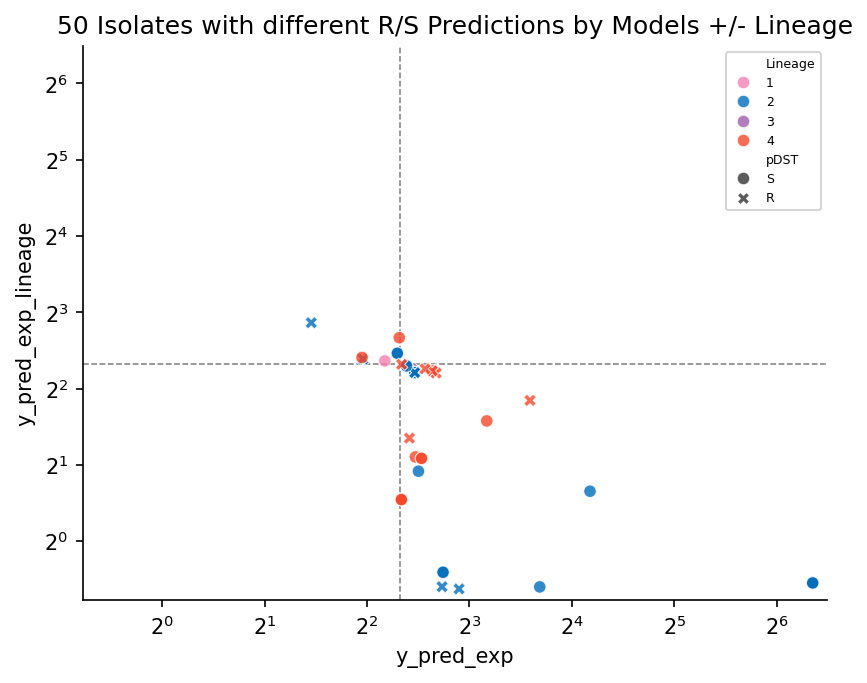

In [342]:
sns.scatterplot(data=df_discrepant,
                x='y_pred_exp',
                y='y_pred_exp_lineage',
                hue='Lineage',
                hue_order=['1', '2', '3', '4'],
                # size='log_fold_change_plot',
                alpha=0.8,
                palette=LinToColor_Dict,
                style='pDST',
                style_order=['S', 'R'],
                markers={'R': 'X', 'S': 'o'}
               )

# both natural numbers (because MICs), so don't have to consider negatives
min_val = df_discrepant[['y_pred_exp', 'y_pred_exp_lineage']].min().min() * 0.9
max_val = df_discrepant[['y_pred_exp', 'y_pred_exp_lineage']].max().max() * 1.1

# 45 degree line
# plt.plot(np.arange(min_val, max_val), np.arange(min_val, max_val), linestyle='--', linewidth=0.75, color='gray', zorder=0)

# critical concentration
plt.axvline(x=cc, linestyle='--', linewidth=0.75, color='gray', zorder=0)
plt.axhline(y=cc, linestyle='--', linewidth=0.75, color='gray', zorder=0)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xscale('log', base=2)
plt.yscale('log', base=2)

plt.title(f"{len(df_discrepant)} Isolates with different R/S Predictions by Models +/- Lineage")

plt.legend(loc='best', fontsize='6')

sns.despine()
plt.show()

In [347]:
df_discrepant.fold_change.min(), df_discrepant.fold_change.max()

(0.008382388190948567, 2.656249933464269)

In [339]:
df_phenos.query("~Lineage.str.contains(',')").groupby("Lineage")[[f"{drug}_midpoint", "Binary"]].mean()

,ETH_midpoint,Binary
Lineage,,
1,3.927495,0.210526
2,3.331335,0.192765
3,1.556303,0.053140
4,3.203958,0.166636


In [290]:
df_phenos.query("category=='test_set'").dropna(subset='Binary').shape

(1073, 19)

In [343]:
search_isolates = df_discrepant.query("Binary == 1").Isolate.values

df_discrepant.query("Binary == 1")[['Isolate', 'lower', 'upper', 'y_pred_exp', 'y_pred_exp_lineage', 'essential_disagree', 'essential_disagree_lineage', 'Lineage', 'Coll2014', 'Binary']]['Coll2014'].value_counts()

Coll2014
2.2.1      7
2.2.2      4
4.2.2      3
3          1
4.1.2.1    1
4.3.2.1    1
4.4.1.1    1
4.7        1
Name: count, dtype: int64

In [344]:
search_isolates = df_discrepant.query("Binary == 0").Isolate.values

df_discrepant.query("Binary == 0")[['Isolate', 'lower', 'upper', 'y_pred_exp', 'y_pred_exp_lineage', 'essential_disagree', 'essential_disagree_lineage', 'Lineage', 'Coll2014', 'Binary']]['Coll2014'].value_counts()

Coll2014
2.2.1      12
4.1.2.1     7
2.2.2       6
2.2.1.1     1
3           1
4.2.2       1
4.3.2.1     1
4.2.2.1     1
1.2.1       1
Name: count, dtype: int64

In [277]:
search_variant = 'inhA_c.-770T>C'

isolates_with_var = isolate_variants.query("variant == @search_variant & ROLLINGDB_ID in @df_phenos.ROLLINGDB_ID").ROLLINGDB_ID.unique()
len(isolates_with_var)

152

In [278]:
df_phenos.query("ROLLINGDB_ID in @isolates_with_var")[['Coll2014']].value_counts().head(10)

Coll2014
2.2.1       119
2.2.1.1       6
4.3.3         5
1.1.2         4
4.1.2.1       4
3             3
4.1           3
1.1.1         1
1.2.1         1
1.2.2         1
Name: count, dtype: int64

In [279]:
119/152

0.7828947368421053

# Low AF Variants for FQs, Bedaquiline

In [8]:
df_MXF = pd.read_csv(os.path.join(data_dir, "MXF", "data_for_model.csv"))
MXF_pred = pd.read_csv(os.path.join(results_dir, "MXF_lineage_amino_acid", "test_predictions.csv"))
MXF_pred["y_pred_exp"] = np.exp2(MXF_pred["y_pred"])

# MXF_isolate_variants = pd.read_csv(os.path.join(data_path, "MXF", "isolate_variants_fixed_annot.csv"))
# MXF_isolate_variants["AF"] = MXF_isolate_variants["AF"].replace('.', 0.76).astype(float)

# LEV_pred = pd.read_csv(os.path.join(results_dir, "LEV_lineage_amino_acid", "test_predictions.csv"))
# LEV_pred["y_pred_exp"] = np.exp2(LEV_pred["y_pred"])

# LEV_isolate_variants = pd.read_csv(os.path.join(data_path, "LEV", "isolate_variants_fixed_annot.csv"))
# LEV_isolate_variants["AF"] = LEV_isolate_variants["AF"].replace('.', 0.76).astype(float)

In [14]:
isolate_variants.query("ROLLINGDB_ID in @MXF_pred.Isolate & AF > 0.25 & AF <= 0.74 & POS >= 4998 & POS <= 9818").drop_duplicates(['ROLLINGDB_ID', 'variant']).sort_values("POS")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
368117,5748,C,T,Amb,5865.0,False,0.61,267.0,39.0,60.0,0.0,0.0,missense_variant,gyrB,c.509C>T,p.Thr170Met,gyrB_p.Thr170Met,NaN,NaN,SAMEA7544066
423259,6575,C,G,Amb,8003.0,False,0.47,246.0,36.0,60.0,0.0,0.0,missense_variant,gyrB,c.1336C>G,p.Arg446Gly,gyrB_p.Arg446Gly,Levofloxacin,3) Uncertain significance,SAMEA7546245
55853,6579,C,T,Amb,2240.0,False,0.64,152.0,34.0,59.0,0.0,0.0,missense_variant,gyrB,c.1340C>T,p.Ser447Phe,gyrB_p.Ser447Phe,Levofloxacin,2) Assoc w R - Interim,TRL0114463
190719,6620,G,A,Amb,75.0,False,0.27,33.0,36.0,60.0,0.0,0.0,missense_variant,gyrB,c.1381G>A,p.Asp461Asn,gyrB_p.Asp461Asn,Levofloxacin,1) Assoc w R,SAMEA1103121
172960,7161,C,A,Del;Amb,12.0,False,0.68,2.0,315.0,3.0,0.0,27.0,missense_variant,gyrB,c.1922C>A,p.Ala641Asp,gyrB_p.Ala641Asp,Levofloxacin,3) Uncertain significance,SAMEA1101608
640618,7566,G,A,Amb,3573.0,False,0.44,129.0,36.0,60.0,0.0,0.0,missense_variant,gyrA,c.265G>A,p.Asp89Asn,gyrA_p.Asp89Asn,Levofloxacin,1) Assoc w R,SAMEA8718844
118279,7570,C,T,Amb,7446.0,False,0.44,257.0,39.0,60.0,0.0,0.0,missense_variant,gyrA,c.269C>T,p.Ala90Val,gyrA_p.Ala90Val,Levofloxacin,1) Assoc w R,SAMN05916382
382254,7570,C,T,Amb,4338.0,False,0.67,363.0,39.0,60.0,0.0,0.0,missense_variant,gyrA,c.269C>T,p.Ala90Val,gyrA_p.Ala90Val,Levofloxacin,1) Assoc w R,SAMEA7544377
177739,7570,C,T,Amb,1171.0,False,0.57,47.0,34.0,59.0,0.0,0.0,missense_variant,gyrA,c.269C>T,p.Ala90Val,gyrA_p.Ala90Val,Levofloxacin,1) Assoc w R,SAMEA1101749
285370,7570,C,T,Amb,4248.0,False,0.54,143.0,35.0,60.0,0.0,0.0,missense_variant,gyrA,c.269C>T,p.Ala90Val,gyrA_p.Ala90Val,Levofloxacin,1) Assoc w R,SAMEA7525873


# Ethionamide: ethA LoF not always predicted to cause R, so look at mshA. Does it activate ETO, leading to S?

## mshA-mediated ethA-independent ETO activation may be possible

Hypothesis: If mshA is still functional, then mshA may activate ETO, leading to ETO-S in the presence of ethA LoF mutations. Because we don't know how any mutations affect mshA, look at the prevalence of any non-silent mutations in mshA and see if they co-occur with ethA LoF mutations.

There are 6 missense mshA mutations in the catalog that are Groups 4-5

Codons 76 and 243 have large significant saliency scores

In [2]:
# remove the isolates whose MICs span the CC
df_ETO_phenos = pd.read_csv(os.path.join(data_dir, "ETO", "data_for_model.csv"))

In [3]:
df_ETO_phenos.ROLLINGDB_ID.nunique(), isolate_variants.query("ROLLINGDB_ID in @df_ETO_phenos.ROLLINGDB_ID").ROLLINGDB_ID.nunique()

(10190, 10188)

## Does the CNN Correctly predict any test isolates that the catalog misses?

In [4]:
df_ETO_test_pred = pd.read_csv(f"{results_dir}/ETO_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")
df_ETO_catalog_pred = pd.read_csv(f"{results_dir}/ETO/catalog_test_predictions_V2.csv").query("Span_CC==0")

cc_thresh = 5
df_ETO_test_pred['Binary'] = (df_ETO_test_pred['lower'] >= cc_thresh).astype(int)

In [5]:
cc_thresh = np.log2(cc_thresh)
isolates_CNN_got_catalog_no = list(set(df_ETO_test_pred.query("y_pred > @cc_thresh & Binary == 0").Isolate).intersection(df_ETO_catalog_pred.query("y_pred==0").ROLLINGDB_ID))
len(isolates_CNN_got_catalog_no)

4

In [6]:
df_insilico_pred_tier1 = pd.read_csv("./supplement/insilico_pred_all.csv").query("drug=='Ethionamide'")
df_insilico_pred_tier2 = pd.read_csv("./results/Ethionamide/insilico_pred_tier2.csv")

In [7]:
df_ETO_addl_interesting = pd.concat([df_insilico_pred_tier2.query("fold_change > 2 & Locus in ['mshA', 'Rv3083', 'Rv0565c', 'ndh']"),
                                       # df_insilico_pred_tier1.query("fold_change > 2 & Locus=='mshA'")
                                      ]).sort_values(['Locus', "fold_change"], ascending=[True, False])

df_ETO_addl_interesting.to_csv("./results/Ethionamide/new_genes_greater_doubling.csv", index=False)

In [8]:
df_ETO_addl_interesting[['Locus', 'effect']].value_counts()

Locus    effect           
mshA     stop_gained          7
Rv0565c  stop_gained          6
Rv3083   inframe_deletion     2
ndh      stop_gained          2
Rv0565c  inframe_insertion    1
         missense_variant     1
Rv3083   stop_gained          1
ndh      start_lost           1
Name: count, dtype: int64

In [9]:
df_ETO_addl_interesting.query("effect == 'missense_variant'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
182,Rv0565c_p.Gly189Arg,1.234198,2.352505,missense_variant,5.0,Rv0565c,3) Uncertain significance,0.957975,2.455705,1.296137,Rv0565c,Ethionamide


In [10]:
isolate_variants.query("variant=='Rv0565c_p.Gly189Arg'").merge(df_ETO_phenos[['ROLLINGDB_ID', 'ETO_lower_bound', 'ETO_upper_bound', 'category', 'Lineage']])

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ETO_lower_bound,ETO_upper_bound,category,Lineage
0,SAMEA7542216,656906,C,T,PASS,8023.0,False,1.0,208.0,39.0,...,Rv0565c,c.565G>A,p.Gly189Arg,Rv0565c_p.Gly189Arg,Ethionamide,3) Uncertain significance,5.0,10.0,train_set,2


In [11]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA7542216' & drug=='Ethionamide'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
350147,SAMEA7542216,656906,C,T,PASS,8023.0,False,1.0,208.0,39.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.565G>A,p.Gly189Arg,Rv0565c_p.Gly189Arg,Ethionamide,3) Uncertain significance
350148,SAMEA7542216,657081,C,T,PASS,8688.0,False,1.0,221.0,39.0,60.0,0.0,0.0,synonymous_variant,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim
350149,SAMEA7542216,657142,C,T,PASS,9053.0,False,1.0,231.0,39.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance
350198,SAMEA7542216,4326676,G,C,PASS,8597.0,False,1.0,223.0,39.0,60.0,0.0,0.0,missense_variant,ethA,c.798C>G,p.Ser266Arg,ethA_p.Ser266Arg,Ethionamide,3) Uncertain significance
350199,SAMEA7542216,4326693,G,A,PASS,8526.0,False,1.0,217.0,39.0,60.0,0.0,0.0,missense_variant,ethA,c.781C>T,p.Arg261Trp,ethA_p.Arg261Trp,Ethionamide,3) Uncertain significance


In [12]:
isolate_variants.query("variant=='ethA_p.Arg261Trp'").merge(df_ETO_phenos[['ROLLINGDB_ID', 'ETO_lower_bound', 'ETO_upper_bound', 'category', 'Lineage']])

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ETO_lower_bound,ETO_upper_bound,category,Lineage
0,SAMN06010185,4326693,G,A,PASS,11204.0,False,1.0,305.0,37.0,...,ethA,c.781C>T,p.Arg261Trp,ethA_p.Arg261Trp,Ethionamide,3) Uncertain significance,0.0,1.25,train_set,4
1,SAMEA7542216,4326693,G,A,PASS,8526.0,False,1.0,217.0,39.0,...,ethA,c.781C>T,p.Arg261Trp,ethA_p.Arg261Trp,Ethionamide,3) Uncertain significance,5.0,10.00,train_set,2


In [13]:
isolate_variants.query("ROLLINGDB_ID=='SAMN06010185' & drug=='Ethionamide'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
143290,SAMN06010185,656739,C,A,PASS,10045.0,False,1.0,268.0,37.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.732G>T,p.Met244Ile,Rv0565c_p.Met244Ile,Ethionamide,3) Uncertain significance
143314,SAMN06010185,4326693,G,A,PASS,11204.0,False,1.0,305.0,37.0,60.0,0.0,0.0,missense_variant,ethA,c.781C>T,p.Arg261Trp,ethA_p.Arg261Trp,Ethionamide,3) Uncertain significance


In [14]:
df_insilico_pred_tier1.query("variant in ['ethA_p.Ser266Arg', 'ethA_p.Arg261Trp']")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
5637,ethA_p.Arg261Trp,1.210006,2.313386,missense_variant,5.0,ethA,3) Uncertain significance,1.002264,2.308161,1.206744,ethA,Ethionamide
6062,ethA_p.Ser266Arg,-0.020187,0.986105,missense_variant,5.0,ethA,3) Uncertain significance,1.002264,0.983878,-0.023449,ethA,Ethionamide


In [15]:
df_insilico_pred_tier2.query("variant in ['ethA_p.Ser266Arg', 'ethA_p.Arg261Trp', 'Rv0565c_p.Gly189Arg', 'Rv0565c_p.Met244Ile']")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug
182,Rv0565c_p.Gly189Arg,1.234198,2.352505,missense_variant,5.0,Rv0565c,3) Uncertain significance,0.957975,2.455705,1.296137,Rv0565c,Ethionamide
240,Rv0565c_p.Met244Ile,-0.061870,0.958021,missense_variant,5.0,Rv0565c,3) Uncertain significance,0.957975,1.000048,0.000069,Rv0565c,Ethionamide
872,ethA_p.Arg261Trp,0.098583,1.070721,missense_variant,5.0,ethA,3) Uncertain significance,0.957975,1.117692,0.160523,ethA,Ethionamide
1297,ethA_p.Ser266Arg,0.002711,1.001881,missense_variant,5.0,ethA,3) Uncertain significance,0.957975,1.045832,0.064651,ethA,Ethionamide


In [16]:
df_ETO_addl_interesting.effect.value_counts()

effect
stop_gained          16
inframe_deletion      2
inframe_insertion     1
missense_variant      1
start_lost            1
Name: count, dtype: int64

In [17]:
isolate_variants.query("variant=='mshA_p.Pro30Leu' & drug=='Ethionamide'").merge(df_ETO_phenos[['ROLLINGDB_ID', 'ETO_lower_bound', 'ETO_upper_bound', 'category', 'Lineage']])

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ETO_lower_bound,ETO_upper_bound,category,Lineage
0,SAMEA1101745,575436,C,T,PASS,3010.0,False,1.0,93.0,33.0,...,mshA,c.89C>T,p.Pro30Leu,mshA_p.Pro30Leu,Ethionamide,3) Uncertain significance,10.0,inf,train_set,3


In [18]:
for gene in ['mshA', 'Rv3083', 'Rv0565c', 'ndh']:
    num_isolates = isolate_variants.query("GENE==@gene & EFFECT=='stop_gained'").merge(df_ETO_phenos).ROLLINGDB_ID.nunique()
    print(gene, num_isolates)

mshA 5
Rv3083 20
Rv0565c 11
ndh 0


In [19]:
# sample_dirs = pd.read_csv("all_dirs.tsv", sep='\t', header=None)[0].values
# len(sample_dirs)

In [20]:
# isolate_variants_combined = []

# for i, dir_name in enumerate(sample_dirs):

#     sample_id = os.path.basename(dir_name)

#     if os.path.isfile(f"{dir_name}/WHO_resistance/{sample_id}_variants_annot.tsv"):
        
#         df_variants = pd.read_csv(f"{dir_name}/WHO_resistance/{sample_id}_variants_annot.tsv", sep='\t')
#         df_variants['ROLLINGDB_ID'] = sample_id
        
#         isolate_variants_combined.append(df_variants)

#     else:
#         print(f"No {sample_id}")
    
#     if i % 1000 == 0:
#         print(i)

# isolate_variants_combined = pd.concat(isolate_variants_combined)

In [21]:
def lof_present_mutations(gene, include_frameshift=False):

    if include_frameshift:
        lof_lst = ['start_lost', 'stop_gained', 'ablation', 'frameshift_variant']
    else:
        lof_lst = ['start_lost', 'stop_gained', 'ablation']

    # get all variants in the gene of interest
    gene_df = isolate_variants.query("GENE == @gene")

    # these fields are NaN for structural variants and many indels, so set them to pass the thresholds
    gene_df['AF'] = gene_df['AF'].fillna(0.76)
    gene_df['DP'] = gene_df['DP'].fillna(5)
    gene_df['IC'] = gene_df['IC'].fillna(5)
    gene_df['DC'] = gene_df['DC'].fillna(5)
    gene_df['MQ'] = gene_df['MQ'].fillna(30)
    gene_df['BQ'] = gene_df['BQ'].fillna(20)
    gene_df['QUAL'] = gene_df['QUAL'].fillna(10)

    # deletions
    gene_df.loc[((gene_df['EFFECT'].str.contains('|'.join(lof_lst))) | (gene_df['variant'].str.contains('deletion'))) &
                (gene_df['REF'].str.len() > gene_df['ALT'].str.len()) & 
                (~gene_df['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) &
                (gene_df['AF'] > 0.25) & 
                (gene_df['DP'] >= 5) & 
                (gene_df['MQ'] >= 30) & 
                (gene_df['DC'] >= 5), 
    f'{gene}_LoF'] = 1

    # insertions
    gene_df.loc[((gene_df['EFFECT'].str.contains('|'.join(lof_lst))) | (gene_df['variant'].str.contains('deletion'))) &
                (gene_df['REF'].str.len() < gene_df['ALT'].str.len()) & 
                (~gene_df['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) &
                (gene_df['AF'] > 0.25) & 
                (gene_df['DP'] >= 5) & 
                (gene_df['MQ'] >= 30) & 
                (gene_df['IC'] >= 5), 
    f'{gene}_LoF'] = 1

    # SNPs/MNPs
    gene_df.loc[((gene_df['EFFECT'].str.contains('|'.join(lof_lst))) | (gene_df['variant'].str.contains('deletion'))) &
                (gene_df['REF'].str.len() == gene_df['ALT'].str.len()) & 
                (~gene_df['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) &
                (gene_df['QUAL'] >= 10) & 
                (gene_df['AF'] > 0.75) & 
                (gene_df['DP'] >= 5) & 
                (gene_df['BQ'] >= 20) & 
                (gene_df['MQ'] >= 30), 
    f'{gene}_LoF'] = 1

    gene_df[f"{gene}_LoF"] = gene_df[f"{gene}_LoF"].fillna(0).astype(int)

    return gene_df

In [25]:
include_frameshift = True

# no frameshift
ethA_annot = lof_present_mutations('ethA', include_frameshift=include_frameshift)
mshA_annot = lof_present_mutations('mshA', include_frameshift=include_frameshift)
Rv0565c_annot = lof_present_mutations('Rv0565c', include_frameshift=include_frameshift)
Rv3083_annot = lof_present_mutations('Rv3083', include_frameshift=include_frameshift)
ndh_annot = lof_present_mutations('ndh', include_frameshift=include_frameshift)
# ndhA_annot = lof_present_mutations('ndhA', include_frameshift=include_frameshift)

df_ETO_phenos = pd.read_csv(os.path.join(data_dir, "ETO", "data_for_model.csv")).query("Span_CC==0")
assert sum(pd.isnull(df_ETO_phenos['Binary'])) == 0

for df in [ethA_annot, mshA_annot, Rv0565c_annot, Rv3083_annot, ndh_annot]:#, ndhA_annot]:

    col_name = df.columns[df.columns.str.contains('LoF')][0]
    
    df_ETO_phenos = df_ETO_phenos.merge(df.sort_values(['ROLLINGDB_ID', col_name], ascending=[True, False])[['ROLLINGDB_ID', col_name]].drop_duplicates(['ROLLINGDB_ID'], keep='first'), on='ROLLINGDB_ID', how='left')

    df_ETO_phenos[col_name] = df_ETO_phenos[col_name].fillna(0).astype(int)

    print(f"{sum(df_ETO_phenos[col_name])} isolates have {col_name.split('_')[0]} LoF mutations")

932 isolates have ethA LoF mutations
32 isolates have mshA LoF mutations
179 isolates have Rv0565c LoF mutations
571 isolates have Rv3083 LoF mutations
32 isolates have ndh LoF mutations


In [26]:
genes_lst = ['ethA', 'mshA', 'Rv0565c', 'Rv3083', 'ndh']#, 'ndhA']

ETO_LoF_summary = pd.DataFrame(df_ETO_phenos[[f"{gene}_LoF" for gene in genes_lst]].value_counts()).reset_index()

ETO_LoF_summary_MIC = df_ETO_phenos.groupby([f"{gene}_LoF" for gene in genes_lst])[['Binary', 'ETO_midpoint']].mean().reset_index()

ETO_LoF_summary = ETO_LoF_summary.merge(ETO_LoF_summary_MIC, on=[f"{gene}_LoF" for gene in genes_lst])

ETO_LoF_summary['total_LoF'] = ETO_LoF_summary[[f"{gene}_LoF" for gene in genes_lst]].sum(axis=1)

ETO_LoF_summary[[f"{gene}_LoF" for gene in genes_lst]] = ETO_LoF_summary[[f"{gene}_LoF" for gene in genes_lst]].replace(0, '').replace(1, '+')

ETO_LoF_summary = ETO_LoF_summary.sort_values('total_LoF')
del ETO_LoF_summary['total_LoF']

In [27]:
ETO_LoF_summary.sort_values('ethA_LoF')

,ethA_LoF,mshA_LoF,Rv0565c_LoF,Rv3083_LoF,ndh_LoF,count,Binary,ETO_midpoint
0,,,,,,8614,0.130834,2.526619
2,,,,+,,373,0.115282,2.522135
5,,,+,,,27,0.555556,7.159722
6,,+,,,,26,0.500000,5.805288
7,,,,,+,25,0.640000,10.310000
3,,,+,+,,118,0.228814,3.689089
11,,+,,+,,4,0.500000,5.281250
12,,+,+,+,,1,1.000000,10.000000
1,+,,,,,831,0.429603,6.173007
4,+,,,+,,60,0.783333,10.132812


In [28]:
ETO_isolates_annotated = df_ETO_phenos.merge(isolate_variants, on='ROLLINGDB_ID', how='left').drop_duplicates(['ROLLINGDB_ID', 'variant'])

isolates_with_group1_2_variants = ETO_isolates_annotated.query("drug=='Ethionamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").ROLLINGDB_ID.unique()

print(f"{len(isolates_with_group1_2_variants)}/{ETO_isolates_annotated.ROLLINGDB_ID.nunique()} isolates have Group 1-2 ethionamide resistance mutations")

ETO_isolates_no_Group12 =  ETO_isolates_annotated.query("ROLLINGDB_ID not in @isolates_with_group1_2_variants")

2411/10120 isolates have Group 1-2 ethionamide resistance mutations


In [29]:
ethA_nonsense = ETO_isolates_annotated.query("EFFECT=='stop_gained' & variant != 'stop_gained' & GENE=='ethA'")
# ethA_nonsense['codon'] = ethA_nonsense['variant'].apply(get_variant_number, args=('+'))

In [30]:
ethA_nonsense.ROLLINGDB_ID.nunique()

190

In [31]:
isolates_with_ndh_LoF = df_ETO_phenos.query("ndh_LoF==1").ROLLINGDB_ID.unique()
len(isolates_with_ndh_LoF)

32

In [32]:
isolates_with_ndh_LoF_and_R_variant = isolate_variants.query("ROLLINGDB_ID in @isolates_with_ndh_LoF & drug=='Ethionamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").ROLLINGDB_ID.unique()
len(isolates_with_ndh_LoF_and_R_variant)

21

In [33]:
remaining_isolates = list(set(isolates_with_ndh_LoF) - set(isolates_with_ndh_LoF_and_R_variant))
len(remaining_isolates)

11

In [36]:
df_ETO_phenos.query("ROLLINGDB_ID in @remaining_isolates").Binary.value_counts()

Binary
0.0    7
1.0    4
Name: count, dtype: int64

In [39]:
df_ETO_phenos.query("ROLLINGDB_ID in @remaining_isolates & Binary == 0").ETO_midpoint.mean()

2.107142857142857

In [40]:
st.mannwhitneyu(ETO_isolates_no_Group12.drop_duplicates('ROLLINGDB_ID').query("ndh_LoF==1").ETO_midpoint,
                ETO_isolates_no_Group12.drop_duplicates('ROLLINGDB_ID').query("ndh_LoF==0").ETO_midpoint,
                alternative='greater'
               )

MannwhitneyuResult(statistic=74195.5, pvalue=2.8353139102343957e-06)

In [71]:
st.ttest_ind(np.log2(ETO_isolates_no_Group12.drop_duplicates('ROLLINGDB_ID').query("ndh_LoF==1").ETO_midpoint),
                np.log2(ETO_isolates_no_Group12.drop_duplicates('ROLLINGDB_ID').query("ndh_LoF==0").ETO_midpoint),
             equal_var=False,
                alternative='greater'
               )

TtestResult(statistic=5.176014612219766, pvalue=0.0002058580612971284, df=10.028249307857196)

ndh_LoF
0    7698
1      11
Name: count, dtype: int64


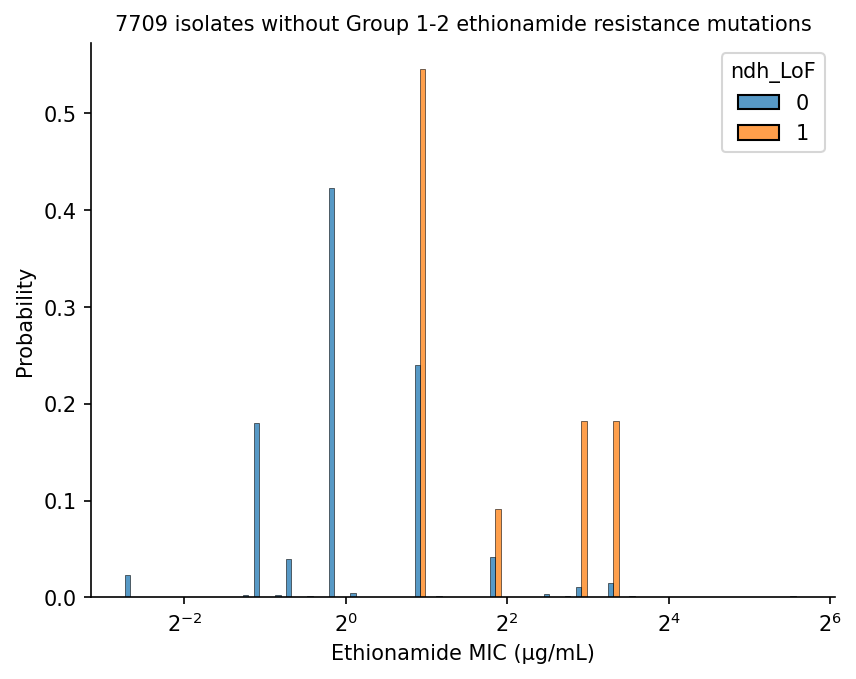

In [67]:
col = 'ndh_LoF'

print(ETO_isolates_no_Group12.drop_duplicates('ROLLINGDB_ID').ndh_LoF.value_counts())

sns.histplot(data=ETO_isolates_no_Group12.drop_duplicates('ROLLINGDB_ID'),
             x='ETO_midpoint',
             hue=col,
             log_scale=2,
             common_norm=False,
             stat='probability',
             multiple='dodge'
            )

plt.xlabel('Ethionamide MIC (µg/mL)')
plt.title(f"{ETO_isolates_no_Group12.ROLLINGDB_ID.nunique()} isolates without Group 1-2 ethionamide resistance mutations", fontsize=10)

sns.despine()
plt.show()

In [65]:
isolate_variants.query("ROLLINGDB_ID in @remaining_isolates & drug=='Ethionamide'")[['variant', 'confidence']].value_counts()

variant              confidence                
ndh_LoF              3) Uncertain significance     11
Rv0565c_c.390G>A     4) Not assoc w R - Interim     6
Rv0565c_p.Arg110His  3) Uncertain significance      4
mshA_p.Ala187Val     5) Not assoc w R               3
ndh_p.Ala324fs       3) Uncertain significance      3
ndh_p.Ile212fs       3) Uncertain significance      2
Rv3083_p.Asp71His    3) Uncertain significance      2
ndh_p.Met1?          3) Uncertain significance      1
ndh_p.Gly331fs       3) Uncertain significance      1
ndh_p.Glu6fs         3) Uncertain significance      1
ndh_p.Gln4fs         3) Uncertain significance      1
ndh_p.Asp288fs       3) Uncertain significance      1
mshA_p.Asp218Ala     3) Uncertain significance      1
inhA_c.321G>A        4) Not assoc w R - Interim     1
mshA_c.730C>T        4) Not assoc w R - Interim     1
ethA_p.Tyr211Cys     3) Uncertain significance      1
ethA_p.Thr44Pro      3) Uncertain significance      1
ethA_p.Ser266Arg     3) Uncertain 

In [81]:
isolate_variants.query("ROLLINGDB_ID in @remaining_isolates & drug=='Ethionamide' & GENE=='ndh' & variant != 'ndh_LoF'").variant.value_counts()

variant
ndh_p.Ala324fs    3
ndh_p.Ile212fs    2
ndh_p.Glu6fs      1
ndh_p.Met1?       1
ndh_p.Pro136fs    1
ndh_p.Gly331fs    1
ndh_p.Gln4fs      1
ndh_p.Asp288fs    1
Name: count, dtype: int64

In [86]:
isolate_variants.query("ROLLINGDB_ID in @isolates_with_ndh_LoF & drug=='Ethionamide' & GENE=='ndh' & variant != 'ndh_LoF'").ROLLINGDB_ID.nunique()

31

In [91]:
df_ETO_phenos.query("ROLLINGDB_ID in @remaining_isolates").ETO_midpoint.median()

1.875

In [90]:
df_ETO_phenos.query("ROLLINGDB_ID in @remaining_isolates").sort_values('ETO_lower_bound')

,ROLLINGDB_ID,ETO_MEDIA,ETO_lower_bound,ETO_midpoint,ETO_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,...,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF,Rv0565c_LoF,Rv3083_LoF,ndh_LoF,ndhA_LoF
247,SAMEA7524913,7H10,1.25,1.875,2.5,UKMYC,CRyPTIC,1.1.2,1.1.2,"indo_oceanic,mungi",...,0,0.0,1-0,test_set,0,0,0,0,1,0
2363,SAMEA1101698,7H10,1.25,1.875,2.5,UKMYC,CRyPTIC,4.2.2,4.2.2.1,tur,...,0,0.0,4-0,train_set,0,0,0,0,1,0
3226,SAMEA7525255,7H10,1.25,1.875,2.5,UKMYC,CRyPTIC,3,3.1.1,"east_african_indian,mungi",...,0,0.0,3-0,train_set,0,0,0,0,1,0
3352,SAMEA7525473,7H10,1.25,1.875,2.5,UKMYC,CRyPTIC,2.2.1,2.2.1.1.1,beijing,...,0,0.0,2-0,validation_set,0,0,0,0,1,0
9582,SAMN05918764,7H10,1.25,1.875,2.5,7H10,farhat_internal,4.1.1,4.1.i1.2.1,xtype,...,0,0.0,4-0,validation_set,0,0,0,0,1,0
9837,SAMN06010374,7H10,1.25,1.875,2.5,7H10,farhat_internal,4.3.3,4.2.1.2.1.1.i4.1,lam,...,0,0.0,4-0,train_set,0,0,0,0,1,0
1769,SAMEA3401667,7H10,3.00,3.500,4.0,7H10,farhat_internal,2.2.1,2.2.1.1.1,beijing,...,0,0.0,2-0,test_set,0,0,0,0,1,0
3286,SAMEA7525357,7H10,5.00,7.500,10.0,UKMYC,CRyPTIC,1.1.2,1.1.2,"indo_oceanic,canetti,mungi",...,0,1.0,1-1,train_set,0,0,0,0,1,0
9211,SAMN02398700,7H10,5.00,7.500,10.0,7H10,farhat_internal,2.2.1,2.2.1.1.1,"beijing,mungi",...,0,1.0,2-1,validation_set,0,0,0,0,1,0
298,SAMEA7525296,7H10,10.00,10.000,inf,UKMYC,CRyPTIC,2.2.1,2.2.1.1.1,"beijing,mungi",...,0,1.0,2-1,test_set,0,0,0,0,1,0


In [94]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA7525296' & drug=='Ethionamide'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
249074,SAMEA7525296,575907,C,T,PASS,4797.0,False,1.00,140.0,34.0,60.0,0.0,0.0,missense_variant,mshA,c.560C>T,p.Ala187Val,mshA_p.Ala187Val,Ethionamide,5) Not assoc w R
249079,SAMEA7525296,657081,C,T,PASS,4208.0,False,1.00,122.0,34.0,60.0,0.0,0.0,synonymous_variant,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim
249080,SAMEA7525296,657142,C,T,PASS,3277.0,False,1.00,98.0,33.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance
249102,SAMEA7525296,2102638,T,TGCGAA,PASS,4275.0,NaN,0.88,124.0,34.0,60.0,NaN,NaN,frameshift_variant,ndh,NaN,NaN,ndh_LoF,Ethionamide,3) Uncertain significance
249105,SAMEA7525296,2102638,T,TGCGAA,PASS,4275.0,False,0.88,124.0,34.0,60.0,109.0,0.0,frameshift_variant,ndh,c.400_404dupTTCGC,p.Pro136fs,ndh_p.Pro136fs,Ethionamide,3) Uncertain significance
249125,SAMEA7525296,4326842,T,C,PASS,3609.0,False,1.00,107.0,34.0,60.0,0.0,0.0,missense_variant,ethA,c.632A>G,p.Tyr211Cys,ethA_p.Tyr211Cys,Ethionamide,3) Uncertain significance


In [82]:
h37Rv_genes.query("Symbol=='ndh'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
1897,1897,CDS,2101651,2103042,-,0.0,Rv1854c,ndh,Transfer of electrons from NADH to the respira...,Probable NADH dehydrogenase Ndh,...,P95160,ML2061,MMAR_2728,MSMEG_3621,Mb1885c,NaN,NaN,NaN,NaN,NaN


In [75]:
df_ETO_test_pred.query("Isolate in @remaining_isolates")

,Isolate,y_test,lower,upper,Span_CC,y_pred,Binary
247,SAMEA7524913,0.906891,1.25,2.5,0,0.313615,0
298,SAMEA7525296,3.321928,10.00,inf,0,1.115359,1
1769,SAMEA3401667,1.807355,3.00,4.0,0,-0.595775,0


In [78]:
np.exp2(-0.595775)

0.6616889076625403

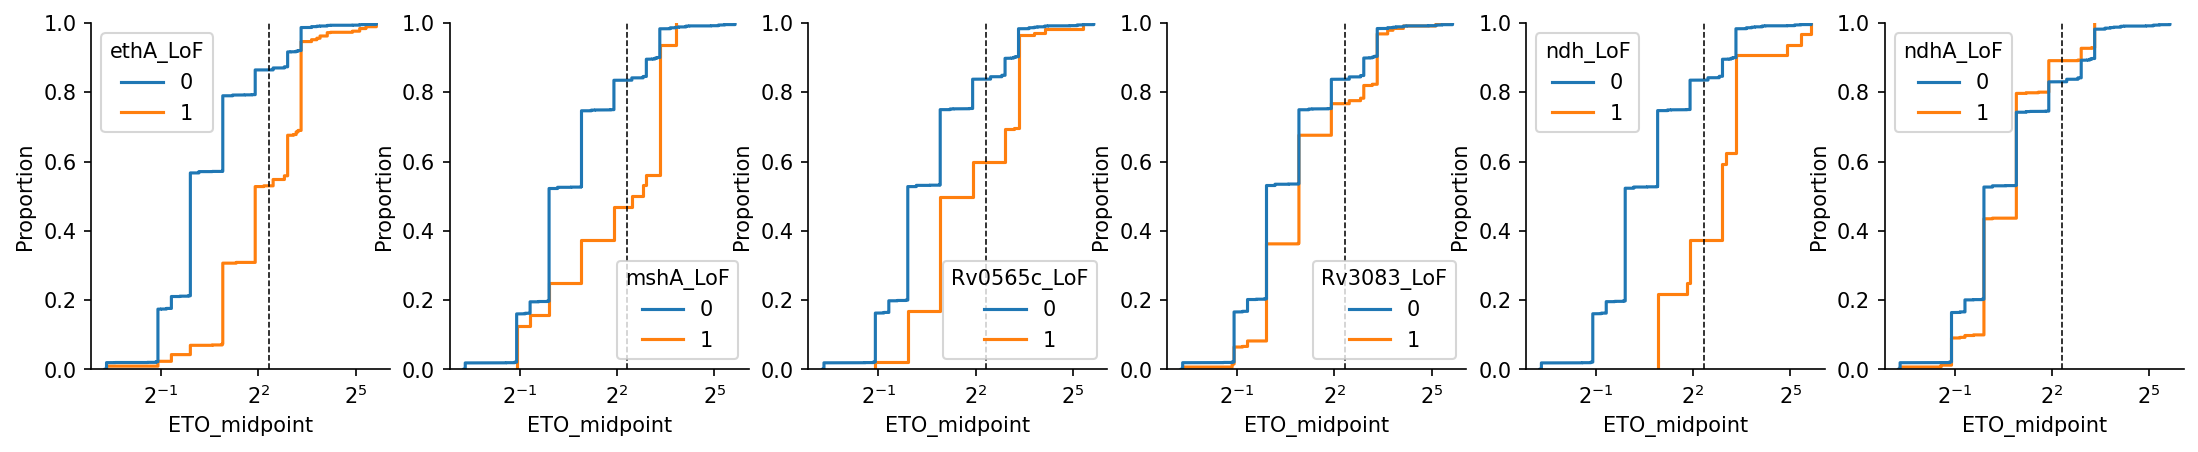

In [144]:
fig, ax = plt.subplots(1, len(genes_lst), figsize=(3*len(genes_lst), 3))

for i, gene in enumerate(genes_lst):

    sns.ecdfplot(data=df_ETO_phenos,
                 x='ETO_midpoint',
                 log_scale=2,
                 hue=f'{gene}_LoF',
                 ax=ax[i]
                )

    ax[i].axvline(5, color='black', linestyle='--', linewidth=0.75)

sns.despine()
plt.show()

In [56]:
df_ETO_phenos

,ROLLINGDB_ID,ETO_MEDIA,ETO_lower_bound,ETO_midpoint,ETO_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,...,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF,Rv0565c_LoF,Rv3083_LoF,ndh_LoF,ndhA_LoF
0,SAMEA104362050,7H10,1.250,1.8750,2.500,UKMYC,CRyPTIC,4.1.2.1,4.1.i1.1.1.1,haarlem,...,0,0.0,4-0,test_set,0,0,0,0,0,0
1,SAMEA104362056,7H10,1.250,1.8750,2.500,UKMYC,CRyPTIC,4.3.3,4.2.1.2.1.1.i4.1,lam,...,0,0.0,4-0,test_set,0,0,0,0,0,0
2,SAMEA104362067,7H10,0.625,0.9375,1.250,UKMYC,CRyPTIC,4.3.2,4.2.1.2.1.1.i1,lam,...,0,0.0,4-0,test_set,0,0,0,0,0,0
3,SAMEA104362073,7H10,0.625,0.9375,1.250,UKMYC,CRyPTIC,4.1.1.3,4.1.i1.2.1,xtype,...,0,0.0,4-0,test_set,0,0,0,0,0,0
4,SAMEA104362077,7H10,10.000,10.0000,inf,UKMYC,CRyPTIC,4.1.2.1,4.1.i1.1.1.1,haarlem,...,0,1.0,4-1,test_set,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10115,SAMN41468253,7H10,6.250,9.3750,12.500,MYCOTB,WHO_catalog,4.7,4,NaN,...,0,1.0,4-1,train_set,0,0,0,0,0,0
10116,SAMN41468263,7H10,0.750,1.1250,1.500,MYCOTB,WHO_catalog,4.3.2,4.2.1.2.1.1.i1,"lam,pinipedii,ethiopian",...,0,0.0,4-0,train_set,0,0,0,0,0,0
10117,SAMN41468273,7H10,0.750,1.1250,1.500,MYCOTB,WHO_catalog,2.2.1.1,2.2.1.1.1,"beijing,mungi",...,0,0.0,2-0,train_set,0,0,0,0,0,0
10118,SAMN41468279,7H10,1.500,2.3125,3.125,MYCOTB,WHO_catalog,4.1,4.1.i1.2.2,"xtype,microti",...,0,0.0,4-0,train_set,0,0,0,0,0,0


In [145]:
len(df_ETO_phenos.query("ndh_LoF==1")), df_ETO_phenos.query("ndh_LoF==1").Binary.value_counts()

(32,
 Binary
 1.0    20
 0.0    12
 Name: count, dtype: int64)

In [146]:
len(df_ETO_phenos.query("ndh_LoF==1 & ethA_LoF==0")), df_ETO_phenos.query("ndh_LoF==1 & ethA_LoF==0").Binary.value_counts()

(25,
 Binary
 1.0    16
 0.0     9
 Name: count, dtype: int64)

In [165]:
df_ndh_nonsense = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/ETO_lineage_tier2_amino_acid/inSilico_analysis/saturation_mutagenesis/ndh/test_predictions.csv")
df_ndh_nonsense['codon'] = df_ndh_nonsense['ROLLINGDB_ID'].apply(get_variant_number, args=('-'))

In [168]:
# sns.scatterplot(data=df_ndh_nonsense,
#                 x='codon',
#                 y='pred_MIC'
#                )

In [171]:
df_ndh_nonsense.sort_values("pred_MIC", ascending=False).head(20)

,ROLLINGDB_ID,category,log2_pred_MIC,pred_MIC,codon
163,ndh_p.Glu386*,NaN,1.726757,3.309829,386
412,ndh_p.Trp393*,NaN,1.693696,3.234843,393
44,ndh_p.Ala392*,NaN,1.677519,3.198774,392
452,ndh_p.Val385*,NaN,1.665435,3.172092,385
43,ndh_p.Ala380*,NaN,1.652885,3.144618,380
329,ndh_p.Phe387*,NaN,1.648456,3.134980,387
36,ndh_p.Ala349*,NaN,1.647680,3.133293,349
271,ndh_p.Leu394*,NaN,1.644453,3.126293,394
270,ndh_p.Leu351*,NaN,1.638450,3.113312,351
330,ndh_p.Phe390*,NaN,1.638080,3.112513,390


In [174]:
isolate_variants.query("GENE=='ndh' & drug=='Ethionamide'").merge(df_ETO_phenos.query("ndh_LoF==1 & ethA_LoF==0"))#[['ROLLINGDB_ID', 'variant']].query("variant != 'ndh_LoF'")#.drop_duplicates(['ROLLINGDB_ID', 'variant'])#.variant.value_counts()

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF,Rv0565c_LoF,Rv3083_LoF,ndh_LoF,ndhA_LoF
0,SAMEA1101698,2103027,CT,C,PASS,0.0,False,1.00,48.0,0.0,...,0,0.0,4-0,train_set,0,0,0,0,1,0
1,SAMEA1101698,2103027,CT,C,PASS,0.0,NaN,1.00,48.0,0.0,...,0,0.0,4-0,train_set,0,0,0,0,1,0
2,SAMEA1101757,2102024,GC,G,Amb,0.0,NaN,0.35,46.0,38.0,...,0,1.0,2-1,train_set,0,0,0,0,1,0
3,SAMEA1101757,2102024,GC,G,Amb,0.0,False,0.35,46.0,38.0,...,0,1.0,2-1,train_set,0,0,0,0,1,0
4,SAMEA3401667,2102072,G,GCC,PASS,3704.0,False,1.00,101.0,37.0,...,0,0.0,2-0,test_set,0,0,0,0,1,0
5,SAMEA3401667,2102072,G,GCC,PASS,3704.0,NaN,1.00,101.0,37.0,...,0,0.0,2-0,test_set,0,0,0,0,1,0
6,SAMEA7524913,2103041,A,G,PASS,2707.0,NaN,0.99,79.0,35.0,...,0,0.0,1-0,test_set,0,0,0,0,1,0
7,SAMEA7524913,2103041,A,G,PASS,2707.0,False,0.99,79.0,35.0,...,0,0.0,1-0,test_set,0,0,0,0,1,0
8,SAMEA7525255,2102409,T,TC,PASS,1609.0,False,0.78,50.0,32.0,...,0,0.0,3-0,train_set,0,0,0,0,1,0
9,SAMEA7525255,2102409,T,TC,PASS,1609.0,NaN,0.78,50.0,32.0,...,0,0.0,3-0,train_set,0,0,0,0,1,0


In [134]:
df_ETO_phenos.query("ndh_LoF==1 & ethA_LoF==0").sort_values("ETO_lower_bound")

,ROLLINGDB_ID,ETO_MEDIA,ETO_lower_bound,ETO_midpoint,ETO_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,...,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF,Rv0565c_LoF,Rv3083_LoF,ndh_LoF,ndhA_LoF
247,SAMEA7524913,7H10,1.25,1.875,2.5,UKMYC,CRyPTIC,1.1.2,1.1.2,"indo_oceanic,mungi",...,0,0.0,1-0,test_set,0,0,0,0,1,0


In [ ]:
include_frameshift

In [118]:
for gene in genes_lst:
    print(df_ETO_phenos.groupby(f'{gene}_LoF')['ETO_midpoint'].mean())

ethA_LoF
0    2.587450
1    6.591591
Name: ETO_midpoint, dtype: float64
mshA_LoF
0    2.946550
1    6.001953
Name: ETO_midpoint, dtype: float64
Rv0565c_LoF
0    2.909866
1    5.530028
Name: ETO_midpoint, dtype: float64
Rv3083_LoF
0    2.908270
1    3.757947
Name: ETO_midpoint, dtype: float64
ndh_LoF
0    2.935639
1    9.441406
Name: ETO_midpoint, dtype: float64
ndhA_LoF
0    2.989824
1    2.383467
Name: ETO_midpoint, dtype: float64


In [194]:
mshA_LoF.merge(df_phenos, on='ROLLINGDB_ID').drop_duplicates(["ROLLINGDB_ID", "variant"])[['ROLLINGDB_ID', 'FILTER', 'POS', 'REF', 'ALT', 'AF', 'BQ', 'MQ', 'DP', 'variant', 'EFFECT', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'category', 'Binary', 'Coll2014', 'Lineage']]

,ROLLINGDB_ID,FILTER,POS,REF,ALT,AF,BQ,MQ,DP,variant,EFFECT,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,category,Binary,Coll2014,Lineage
0,SAMEA3392629,PASS,575511,C,A,1.0,35.0,60.0,61.0,mshA_p.Ser55*,stop_gained,0.0000,5.00000,10.000,test_set,NaN,4,4
1,SAMEA5282343,PASS,576633,C,A,1.0,35.0,60.0,132.0,mshA_p.Ser429*,stop_gained,0.0000,0.62500,1.250,test_set,0.0,4,4
3,SAMEA1101660,PASS,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,NaN,NaN,NaN,NaN,mshA_deletion,transcript_ablation,10.0000,10.00000,inf,train_set,1.0,3,3
5,SAMEA1101792,PASS,576058,GGTCCATCCCGGTGTCGATCTGGACGTGTTCCGCCCGGGTGATCGG...,GTGCCTTCAGCGGCTGGATGCGTCCGACGAAGGCCACCACGCGCTC...,NaN,NaN,NaN,NaN,mshA_p.Val238fs,frameshift_variant&stop_gained,10.0000,10.00000,inf,train_set,1.0,3,3
7,SAMEA7526397,PASS,576278,G,T,1.0,35.0,60.0,71.0,mshA_p.Gly311*,stop_gained,10.0000,10.00000,inf,train_set,1.0,3.1.2,3
9,SAMEA7541537,PASS,576729,C,A,1.0,38.0,60.0,82.0,mshA_p.Ser461*,stop_gained,0.3125,0.46875,0.625,train_set,0.0,2.2.1.1,2


In [200]:
Rv0565c_LoF.merge(df_phenos, on='ROLLINGDB_ID').drop_duplicates(["ROLLINGDB_ID", "variant"])[['ROLLINGDB_ID', 'FILTER', 'POS', 'REF', 'ALT', 'AF', 'BQ', 'MQ', 'DP', 'variant', 'EFFECT', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'category', 'Binary', 'Coll2014', 'Lineage']]

,ROLLINGDB_ID,FILTER,POS,REF,ALT,AF,BQ,MQ,DP,variant,EFFECT,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,category,Binary,Coll2014,Lineage
0,JPN-R2012-0010,PASS,657257,C,A,1.00,35.0,60.0,94.0,Rv0565c_p.Glu72*,stop_gained,4.0000,6.00000,8.000,test_set,NaN,4.5,4
1,KOR-K2016-0229,PASS,656094,C,T,1.00,35.0,59.0,191.0,Rv0565c_p.Trp459*,stop_gained,0.5000,0.75000,1.000,train_set,0.0,4.9,4
2,SAMN02360566,PASS,657108,C,T,0.99,36.0,60.0,112.0,Rv0565c_p.Trp121*,stop_gained,5.0000,7.50000,10.000,validation_set,1.0,2.2.2,2
3,SAMN02360615,PASS,657109,C,T,1.00,37.0,60.0,104.0,Rv0565c_p.Trp121*,stop_gained,2.5000,3.75000,5.000,train_set,0.0,2.2.2,2
4,SAMN05916344,PASS,656674,C,T,0.86,37.0,60.0,265.0,Rv0565c_p.Trp266*,stop_gained,15.0000,17.50000,20.000,train_set,1.0,4.3.3,4
5,SAMEA7524813,PASS,656674,C,T,1.00,35.0,60.0,81.0,Rv0565c_p.Trp266*,stop_gained,10.0000,10.00000,inf,train_set,1.0,1.1.2,1
6,SAMEA7541845,PASS,657033,G,C,1.00,38.0,60.0,101.0,Rv0565c_p.Tyr146*,stop_gained,0.6250,0.93750,1.250,train_set,0.0,4.4.1.1,4
7,SAMEA7544255,PASS,657204,G,T,1.00,38.0,60.0,255.0,Rv0565c_p.Tyr89*,stop_gained,0.3125,0.46875,0.625,train_set,0.0,2.2.1,2
8,SAMEA8741415,PASS,656087,G,A,1.00,39.0,60.0,60.0,Rv0565c_p.Arg462*,stop_gained,2.5000,3.75000,5.000,train_set,0.0,2.2.1,2
9,SAMEA8741575,PASS,656087,G,A,1.00,39.0,60.0,98.0,Rv0565c_p.Arg462*,stop_gained,5.0000,7.50000,10.000,validation_set,1.0,2.2.1,2


In [203]:
h37Rv_genes.query("Symbol=='Rv0565c'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
580,580,CDS,656010,657470,-,0.0,Rv0565c,Rv0565c,Function unknown; probably involved in cellula...,Probable monooxygenase,...,O53762,"ML2281,ML2281c",MMAR_0917,MSMEG_2038,Mb0580c,NaN,NaN,NaN,NaN,NaN


In [206]:
(657470-656010+1)/3

487.0

In [185]:
mshA_fs_isolates = mshA_LoF.query("variant.str.contains('fs')").merge(df_phenos, on='ROLLINGDB_ID').dropna(subset='Binary').drop_duplicates(["ROLLINGDB_ID", "variant"])[['ROLLINGDB_ID', 'FILTER', 'POS', 'REF', 'ALT', 'AF', 'BQ', 'MQ', 'DP', 'variant', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'category', 'Binary', 'Coll2014', 'Lineage']]

mshA_fs_isolates.ROLLINGDB_ID.nunique(), mshA_fs_isolates.variant.nunique()

(24, 18)

In [174]:
mshA_LoF.query("~variant.str.contains('fs')").merge(df_phenos, on='ROLLINGDB_ID').drop_duplicates(["ROLLINGDB_ID", "variant"])[['ROLLINGDB_ID', 'FILTER', 'POS', 'REF', 'ALT', 'AF', 'BQ', 'MQ', 'DP', 'variant', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'category', 'Binary', 'Coll2014', 'Lineage']]

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V2,confidence_V2,drug_V1,confidence_V1
230654,SAMN06094080,576015,AAGTGATTTC,A,PASS,0.0,False,0.91,130.0,38.0,60.0,disruptive_inframe_deletion,mshA,c.669_677delAGTGATTTC,p.Val224_Ser226del,mshA_p.Val224_Ser226del,Ethionamide,3) Uncertain significance,NaN,NaN
230655,SAMN06094080,576015,AAGTGATTTC,A,PASS,0.0,False,0.91,130.0,38.0,60.0,disruptive_inframe_deletion,mshA,c.669_677delAGTGATTTC,p.Val224_Ser226del,mshA_p.Val224_Ser226del,Isoniazid,3) Uncertain significance,NaN,NaN


In [170]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA1101660' & GENE=='mshA'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V2,confidence_V2,drug_V1,confidence_V1
269742,SAMEA1101660,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,NaN,transcript_ablation,mshA,NaN,NaN,mshA_deletion,Ethionamide,3) Uncertain significance,NaN,NaN
269743,SAMEA1101660,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,NaN,transcript_ablation,mshA,NaN,NaN,mshA_deletion,Isoniazid,3) Uncertain significance,NaN,NaN


In [126]:
mshA_LoF.query("variant.str.contains('ablation')")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V1,confidence_V1,drug_V2,confidence_V2


In [168]:
df_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/cryptic_output/SAMEA1101660/WHO_resistance/SAMEA1101660_variants_annot.tsv", sep='\t')

In [135]:
df_protein_seqs.query("mshA_AA.str.startswith('-')")#['mshA_AA'].values

,category,ROLLINGDB_ID,fabG1_AA,inhA_AA,ethA_AA,ethR_AA,mshA_AA,Rv0565c_AA,ndh_AA,Rv3083_AA
1501,train_set,SAMEA1101660,MTATATEGAKPPFVSRSVLVTGGNRGIGLAIAQRLAADGHKVAVTH...,MTGLLDGKRILVSGIITDSSIAFHIARVAQEQGAQLVLTGFDRLRL...,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MTTSAASQASLPRGRRTARPSGDDRELAILATAENLLEDRPLADIS...,----------------------------------------------...,MSVTPNAGCVDVVIVGAGISGLGAAYRIIERNPQLTYTILERRARI...,MSPQQEPTAQPPRRHRVVIIGSGFGGLNAAKKLKRADVDIKLIART...,MNQHFDVLIIGAGLSGIGTACHVTAEFPDKTIALLERRERLGGTWD...
2911,train_set,SAMEA7525795,MTATATEGAKPPFVSRSVLVTGGNRGIGLAIAQRLAADGHKVAVTH...,MTGLLDGKRILVSGIITDSSIAFHIARVAQEQGAQLVLTGFDRLRL...,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MTTSAASQASLPRGRRTARPSGDDRELAILATAENLLEDRPLADIS...,----------------------------------------------...,MSVTPNAGCVDVVIVGAGISGLGAAYRIIERNPQLTYTILERRARI...,MSPQQEPTAQPPRRHRVVIIGSGFGGLNAAKKLKRADVDIKLIART...,MNQHFDVLIIGAGLSGIGTACHVTAEFPDKTIALLERRERLGGTWD...


In [ ]:
bcftools filter -i "POS > 575300 & POS <= 576790" SAMEA1101660.vcf

In [140]:
model_loci.query("Locus=='mshA'")

,Locus,Start,End,Sense
13,mshA,575300,576790,+


In [141]:
isolate_variants.query("ROLLINGDB_ID in ['SAMEA1101660', 'SAMEA7525795'] & POS > 575300 & POS <= 576790")# & GENE=='mshA'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V1,confidence_V1,drug_V2,confidence_V2


In [110]:
len(df_ETO_phenos.query("ethA_LoF==1")), len(df_ETO_phenos.query("ethA_LoF==1 & ETH_upper_bound <= 5"))

(854, 449)

In [111]:
452/858

0.5268065268065268

In [112]:
df_ETO_phenos.query("ethA_LoF==1 & ETH_upper_bound <= 5").Binary.unique()

array([0.])

In [207]:
df_ETO_phenos.groupby(['ethA_LoF', 'mshA_LoF', 'Rv0565c_LoF'])[['ETH_midpoint', 'Binary']].mean().merge(pd.DataFrame(df_ETO_phenos.groupby(['ethA_LoF', 'mshA_LoF', 'Rv0565c_LoF'])['ROLLINGDB_ID'].count()), left_index=True, right_index=True)

ETH_midpoint    Binary  ROLLINGDB_ID
ethA_LoF mshA_LoF Rv0565c_LoF                                      
0        0        0                2.757718  0.138981          9739
                  1                4.582466  0.294118           154
         1        0                4.917500  0.458333            25
                  1               10.000000  1.000000             1
1        0        0                7.163371  0.458629           854
                  1                9.902778  0.851852            27
         1        0                7.100000  0.750000             4

In [39]:
df_ETO_phenos.query("ethA_LoF==0 & (mshA_LoF==1 | Rv0565c_LoF==1)").sort_values('ETH_lower_bound')#['ETH_midpoint'].mean()

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF,Rv0565c_LoF
891,SAMEA5282343,7H10,0.0000,0.62500,1.250,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.008116,4,...,NaN,4,4,0,0.0,4-0,test_set,0,1,0
3477,SAMEA7541537,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010707,2.2.1.1,...,"lin2.2.1,pacific_RD150",NaN,2,0,0.0,2-0,train_set,0,1,0
4300,SAMEA7544255,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.009528,2.2.1,...,lin2.2.1,NaN,2,0,0.0,2-0,train_set,0,0,1
10293,KOR-K2016-0229,7H10,0.5000,0.75000,1.000,MGIT,JATA-KIT,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.010006,4.9,...,NaN,4.10/PGG3,4,0,0.0,4-0,train_set,0,0,1
3686,SAMEA7541845,7H10,0.6250,0.93750,1.250,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.006251,4.4.1.1,...,NaN,4,4,0,0.0,4-0,train_set,0,0,1
8364,SAMEA8741415,7H10,2.5000,3.75000,5.000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.012225,2.2.1,...,"europe/russia_B0/W148_outbreak,lin2.2.1",NaN,2,0,0.0,2-0,train_set,0,0,1
9154,SAMN02360615,7H10,2.5000,3.75000,5.000,7H10,PATRIC_20191206,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.007430,2.2.2,...,"asia_ancestral_1,lin2.2",NaN,2,0,0.0,2-0,train_set,0,0,1
8471,SAMEA8741575,7H10,5.0000,7.50000,10.000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010704,2.2.1,...,"europe/russia_B0/W148_outbreak,lin2.2.1",NaN,2,0,1.0,2-1,validation_set,0,0,1
9127,SAMN02360566,7H10,5.0000,7.50000,10.000,7H10,PATRIC_20191206,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.009017,2.2.2,...,"asia_ancestral_1,lin2.2",NaN,2,0,1.0,2-1,validation_set,0,0,1
1501,SAMEA1101660,7H10,10.0000,10.00000,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.011624,3,...,NaN,NaN,3,0,1.0,3-1,train_set,0,1,0


In [130]:
df_protein_seqs = pd.read_csv(os.path.join(results_dir, "ETH", "df_protein_seqs.csv"))

In [124]:
# verified this using the gene coordinates too
mshA_ref_len = len(df_protein_seqs.query("ROLLINGDB_ID=='MT_H37Rv'")['mshA_AA'].values[0].replace('-', ''))
print(mshA_ref_len)

# stop codon lost is found in 3 ETH-resistant isolates
mshA_diff_length = df_protein_seqs.loc[df_protein_seqs['mshA_AA'].str.replace('-', '').str.len() != mshA_ref_len][['ROLLINGDB_ID', 'ethA_AA', 'mshA_AA', 'category']]
mshA_diff_length['mshA_length'] = df_protein_seqs['mshA_AA'].str.replace('-', '').str.len()
print(len(mshA_diff_length))

480
28


In [127]:
sessential_disagreerch_lst = mshA_diff_length.query("mshA_length > @mshA_ref_len").ROLLINGDB_ID.values

In [129]:
# isolate_variants.query("ROLLINGDB_ID in @sessential_disagreerch_lst & GENE=='mshA'")

In [ ]:
isolate_variants.loc[(isolate_variants['GENE']=='inhA') & 
                        (isolate_variants['REF'].str.len() > isolate_variants['ALT'].str.len()) & 
                                 ((isolate_variants['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) |
                                 (isolate_variants['AF'] <= 0.75) | (isolate_variants['DP'] < 5))
                                ]

In [75]:
mshA_diff_length_variants = isolate_variants.loc[(isolate_variants['GENE']=='mshA') & 
                                 (isolate_variants['EFFECT'].str.contains('|'.join(['start_lost', 'stop_gained', 'frameshift']))) &
                                 (~isolate_variants['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) &
                                 ~(isolate_variants['AF'] <= 0.75) & 
                                 ~(isolate_variants['DP'] < 5) & 
                                (isolate_variants['ROLLINGDB_ID'].isin(mshA_diff_length['ROLLINGDB_ID']))
                                ].drop_duplicates(['ROLLINGDB_ID', 'variant'])

mshA_diff_length_variants['codon'] = mshA_diff_length_variants['variant'].apply(get_variant_number, args=('+'))

# add MICs
mshA_diff_length_variants = mshA_diff_length_variants.merge(df_ETO_phenos[['ROLLINGDB_ID', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'Binary', 'category']])

# add mshA protein lengths
mshA_diff_length_variants = mshA_diff_length_variants.merge(mshA_diff_length[['ROLLINGDB_ID', 'mshA_length']])

In [27]:
isolate_variants.loc[(isolate_variants['GENE']=='mshA') & 
                                 (isolate_variants['EFFECT'].str.contains('|'.join(['frameshift']))) &
                                 (~isolate_variants['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) &
                                 ~(isolate_variants['AF'] <= 0.75) & 
                                 ~(isolate_variants['DP'] < 5) & 
(isolate_variants['ROLLINGDB_ID'].isin(df_ETO_phenos.dropna(subset="Binary")['ROLLINGDB_ID'])) & (isolate_variants['variant'].str.contains('fs'))
].ROLLINGDB_ID.nunique()

24

In [28]:
isolate_variants.loc[(isolate_variants['GENE']=='mshA') & 
                                 (isolate_variants['EFFECT'].str.contains('|'.join(['frameshift']))) &
                                 (~isolate_variants['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) &
                                 ~(isolate_variants['AF'] <= 0.75) & 
                                 ~(isolate_variants['DP'] < 5) & 
(isolate_variants['ROLLINGDB_ID'].isin(df_ETO_phenos.dropna(subset="Binary")['ROLLINGDB_ID'])) & (isolate_variants['variant'].str.contains('fs'))
].variant.nunique()

18

In [133]:
who_variants.query("variant=='pncA_p.Arg140fs'")[['Present_SOLO_R', 'Present_SOLO_S']]

,Present_SOLO_R,Present_SOLO_S
35812,6.0,0.0


In [96]:
mshA_diff_length_variants.query("ETH_midpoint > 5 & codon >= 150 & codon <= 350")[['ROLLINGDB_ID', 'variant', 'drug_V2', 'confidence_V2', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'Binary', 'category', 'mshA_length']]

,ROLLINGDB_ID,variant,drug_V2,confidence_V2,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,Binary,category,mshA_length
3,SAMN06094112,mshA_p.Leu157fs,Ethionamide,3) Uncertain significance,6.0,7.0,8.0,1.0,train_set,219
4,SAMEA1101792,mshA_p.Val238fs,Ethionamide,3) Uncertain significance,10.0,10.0,inf,1.0,train_set,255
10,SAMEA7525944,mshA_p.Thr176fs,Ethionamide,3) Uncertain significance,10.0,10.0,inf,1.0,validation_set,219
11,SAMEA7526397,mshA_p.Gly311*,Ethionamide,3) Uncertain significance,10.0,10.0,inf,1.0,test_set,310
13,SAMEA7561337,mshA_p.Ala279fs,Ethionamide,3) Uncertain significance,10.0,10.0,inf,1.0,train_set,326
14,SAMEA7561425,mshA_p.Ala279fs,Ethionamide,3) Uncertain significance,10.0,10.0,inf,1.0,train_set,326
17,SAMEA8741200,mshA_p.His175fs,Ethionamide,3) Uncertain significance,10.0,10.0,inf,1.0,train_set,183


In [83]:
mshA_diff_length_variants.query("variant.str.endswith('*')")[['ROLLINGDB_ID', 'variant', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'Binary', 'category', 'mshA_length']]

,ROLLINGDB_ID,variant,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,Binary,category,mshA_length
0,SAMEA3392629,mshA_p.Ser55*,0.0000,5.00000,10.000,NaN,test_set,54
1,SAMEA5282343,mshA_p.Ser429*,0.0000,0.62500,1.250,0.0,train_set,428
11,SAMEA7526397,mshA_p.Gly311*,10.0000,10.00000,inf,1.0,test_set,310
12,SAMEA7541537,mshA_p.Ser461*,0.3125,0.46875,0.625,0.0,train_set,460


This is more of a simulation because essential_disagreerly stop codons are very rare in mshA. There are only 4 observed in this dataset -- at codons 55, 311, 429, and 461. However, the isolates with stop codons at 429 and 461 are ETH-S, and the isolate with a stop codon at 311 is ETH-R. The isolate with a stop codon at 55 has a recorded MIC of (0, 10] and was not tested at a concentration of 5 µg/mL. Frameshift mutations are considerably more common mshA. 

Three isolates with loss of a stop codon in mshA due to the same frameshift on the last codon are all resistant, suggesting a possible association with resistance. All three are L3.1.1 and also share a single variant in ethA -- ethA_p.Asn287_Leu333del, which is of uncertain significance in the 2023 WHO mutation catalog.

In [94]:
df_pred = pd.read_csv(os.path.join(results_dir, "ETH_linessential_disagreege_amino_acid", "test_predictions.csv"))
df_pred.query("Isolate=='SAMessential_disagree3392629'")

,Isolate,y_test,lower,upper,Span_CC,y_pred
1073,SAMEA3392629,2.321928,0.0,10.0,1,3.134888


In [113]:
regression_who_results.query("mutation=='ethA_p.Asn287_Leu333del'")[['WHO_BH_pval', 'ALL_BH_pval']]

,WHO_BH_pval,ALL_BH_pval
9977,0.67482,0.567647


In [65]:
mshA_diff_length_variants.query("mshA_length > 450").sort_values("ETH_lower_bound")[['ROLLINGDB_ID', 'variant', 'drug_V2', 'confidence_V2', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'Binary', 'category', 'mshA_length']]

,ROLLINGDB_ID,variant,drug_V2,confidence_V2,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,Binary,category,mshA_length
5,SAMEA1103157,mshA_p.Ala372fs,Ethionamide,3) Uncertain significance,0.3125,0.46875,0.625,0.0,train_set,481
13,SAMEA7541537,mshA_p.Ser461*,Ethionamide,3) Uncertain significance,0.3125,0.46875,0.625,0.0,train_set,460
20,SAMEA7564184,mshA_p.Gln453fs,NaN,NaN,0.6250,0.93750,1.250,0.0,test_set,482
17,SAMEA7563257,mshA_p.Ter481fs,NaN,NaN,5.0000,7.50000,10.000,1.0,train_set,481
16,SAMEA7563230,mshA_p.Ter481fs,NaN,NaN,10.0000,10.00000,inf,1.0,train_set,481
22,SAMEA8742358,mshA_p.Ala422fs,Ethionamide,3) Uncertain significance,10.0000,10.00000,inf,1.0,train_set,481


In [67]:
isolate_variants.query("variant=='mshA_p.Ter481fs'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V1,confidence_V1,drug_V2,confidence_V2
877523,SAMEA7563230,576782,G,GGC,PASS,2932.0,False,1.00,84.0,35.0,60.0,frameshift_variant&stop_lost&splice_region_var...,mshA,c.1439_1440dupCG,p.Ter481fs,mshA_p.Ter481fs,NaN,NaN,NaN,NaN
879489,SAMEA7563256,576782,G,GGC,PASS,2731.0,False,0.71,79.0,35.0,60.0,frameshift_variant&stop_lost&splice_region_var...,mshA,c.1439_1440dupCG,p.Ter481fs,mshA_p.Ter481fs,NaN,NaN,NaN,NaN
879573,SAMEA7563257,576782,G,GGC,PASS,2998.0,False,0.90,87.0,35.0,60.0,frameshift_variant&stop_lost&splice_region_var...,mshA,c.1439_1440dupCG,p.Ter481fs,mshA_p.Ter481fs,NaN,NaN,NaN,NaN


In [108]:
isolate_variants.query("ROLLINGDB_ID in ['SAMessential_disagree7563230', 'SAMessential_disagree7563256', 'SAMessential_disagree7563257'] & GENE=='ethA'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V1,confidence_V1,drug_V2,confidence_V2
877576,SAMEA7563230,4326474,GCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCG...,G,PASS,0.0,False,NaN,NaN,NaN,NaN,conservative_inframe_deletion,ethA,c.859_999del,p.Asn287_Leu333del,ethA_p.Asn287_Leu333del,NaN,NaN,Ethionamide,3) Uncertain significance
879541,SAMEA7563256,4326474,GCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCG...,G,PASS,0.0,False,NaN,NaN,NaN,NaN,conservative_inframe_deletion,ethA,c.859_999del,p.Asn287_Leu333del,ethA_p.Asn287_Leu333del,NaN,NaN,Ethionamide,3) Uncertain significance
879625,SAMEA7563257,4326474,GCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCG...,G,PASS,0.0,False,NaN,NaN,NaN,NaN,conservative_inframe_deletion,ethA,c.859_999del,p.Asn287_Leu333del,ethA_p.Asn287_Leu333del,NaN,NaN,Ethionamide,3) Uncertain significance


In [103]:
df_protein_seqs.query("ROLLINGDB_ID=='SAMessential_disagree7563230'")['mshA_AA'].str.replace('-', '').str.len()

7138    481
Name: mshA_AA, dtype: int64

In [106]:
df_protein_seqs.query("ROLLINGDB_ID=='SAMessential_disagree7563230'")['mshA_AA'].str.replace('-', '').values[0]

'MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRRVALLAVHTSPLAQPGTGDAGGMNVYMLQSALHLARRGIEVEIFTRATASADPPVVRVAPGVLVRNVVAGPFEGLDKYDLPTQLCAFAAGVLRAEAVHEPGYYDIVHSHYWLSGQVGWLARDRWAVPLVHTAHTLAAVKNAALADGDGPEPPLRTVGEQQVVDEADRLIVNTDDEARQVISLHGADPARIDVVHPGVDLDVFRPGDRRAARAALGLPVDERVVAFVGRIQPLKAPDIVLRAAAKLPGVRIIVAGGPSGSGLASPDGLVRLADELGISARVTFLPPQSHTDLATLFRAADLVAVPSYSESFGLVAVEAQACGTPVVAAAVGGLPVAVRDGITGTLVSGHEVGQWADAIDHLLRLCAGPRGRVMSRAAARHAATFSWENTTDALLASYRRAIGEYNAERQRRGGEVISDLVAVGKPRHWTPRRGVGAR'

In [70]:
df_ETO_phenos.query("ROLLINGDB_ID in ['SAMessential_disagree7563230', 'SAMessential_disagree7563256', 'SAMessential_disagree7563257']")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category,ethA_LoF,mshA_LoF
7138,SAMEA7563230,7H10,10.0,10.0,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.009661,3.1.1,...,"east_african_indian,ghana,mungi",NaN,NaN,0,1.0,3,3-1,train_set,0,1
7156,SAMEA7563256,7H10,10.0,10.0,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010240,3.1.1,...,"east_african_indian,ghana,mungi",NaN,NaN,0,1.0,3,3-1,train_set,0,0
7157,SAMEA7563257,7H10,5.0,7.5,10.0,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010986,3.1.1,...,"east_african_indian,ghana,mungi",NaN,NaN,0,1.0,3,3-1,train_set,0,1


In [63]:
isolate_variants.query("ROLLINGDB_ID in ['SAMessential_disagree7563230', 'SAMessential_disagree8742358'] & GENE=='ethA'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V1,confidence_V1,drug_V2,confidence_V2
877576,SAMEA7563230,4326474,GCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCG...,G,PASS,0.0,False,NaN,NaN,NaN,NaN,conservative_inframe_deletion,ethA,c.859_999del,p.Asn287_Leu333del,ethA_p.Asn287_Leu333del,NaN,NaN,Ethionamide,3) Uncertain significance
1085382,SAMEA8742358,4326992,A,C,PASS,4187.0,False,1.0,113.0,37.0,60.0,missense_variant,ethA,c.482T>G,p.Ile161Ser,ethA_p.Ile161Ser,Ethionamide,3) Uncertain significance,Ethionamide,3) Uncertain significance


In [478]:
df_ETO_phenos.query("ethA_LoF == 1 & mshA_LoF == 1")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category,ethA_LoF,mshA_LoF
1888,SAMEA5569690,7H10,10.0,10.0,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.002927,4.3.4.2,...,lam,NaN,4.3/LAM,0,1.0,4,4-1,train_set,1,1
9171,SAMN02360618,7H10,0.6,0.9,1.2,7H10,PATRIC_20191206,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.009341,2.2.1,...,"beijing,east_african_indian,mungi",lin2.2.1,NaN,0,0.0,2,2-0,train_set,1,1


In [484]:
df_ETO_phenos.query("ethA_LoF == 0 & mshA_LoF == 1")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category,ethA_LoF,mshA_LoF
247,SAMEA7526397,7H10,10.0000,10.00000,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.008058,3.1.2,...,"east_african_indian,ghana,mungi",NaN,NaN,0,1.0,3,3-1,test_set,0,1
729,SAMEA7564184,7H10,0.6250,0.93750,1.250,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.011422,2.2.1,...,"beijing,mungi","asian_african_1,lin2.2.1",NaN,0,0.0,2,2-0,test_set,0,1
1564,SAMEA1101792,7H10,10.0000,10.00000,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010370,3,...,"east_african_indian,ghana,mungi",NaN,NaN,0,1.0,3,3-1,train_set,0,1
1727,SAMEA1103157,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.016592,3,...,"east_african_indian,tur,ghana,mungi",NaN,NaN,0,0.0,3,3-0,train_set,0,1
1847,SAMEA5569642,7H10,1.2500,1.87500,2.500,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.012280,4,...,canetti,NaN,4,0,0.0,4,4-0,validation_set,0,1
2189,SAMEA5570058,7H10,2.5000,3.75000,5.000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.011326,4,...,canetti,NaN,4,0,0.0,4,4-0,train_set,0,1
2307,SAMEA7524880,7H10,10.0000,10.00000,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010895,2.2.1,...,"beijing,mungi,canetti","lin2.2.1,asian_african_2",NaN,0,1.0,2,2-1,train_set,0,1
2548,SAMEA7525236,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.012682,3,...,"east_african_indian,mungi",NaN,NaN,0,0.0,3,3-0,train_set,0,1
2551,SAMEA7525241,7H10,0.6250,0.93750,1.250,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.014796,3,...,east_african_indian,NaN,NaN,0,0.0,3,3-0,train_set,0,1
2635,SAMEA7525363,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.012914,4.5,...,canetti,NaN,4.5,0,0.0,4,4-0,train_set,0,1


In [26]:
isolates_with_ethA_LoF_ETO_S = df_ETO_phenos.query("ROLLINGDB_ID in @isolates_with_ethA_LoF & Binary==0").ROLLINGDB_ID.unique()
isolates_with_ethA_LoF_ETO_R = df_ETO_phenos.query("ROLLINGDB_ID in @isolates_with_ethA_LoF & Binary==1").ROLLINGDB_ID.unique()

print(len(isolates_with_ethA_LoF_ETO_S), len(isolates_with_ethA_LoF_ETO_R))

# ~ 1/2 of these isolates are ETO-S
# 1 - df_ETO_phenos.query("ROLLINGDB_ID in @isolates_with_ethA_LoF")['Binary'].essential_disag()

124 106


In [431]:
mshA_start = 575300
mshA_end = 576790

exclude_variants = ['mshA_p.Ala187Val', 'mshA_p.Asn111Ser']

isolate_variants.query("POS > @mshA_start & POS <= @mshA_end & drug_V2=='Ethionamide' & ROLLINGDB_ID in @isolates_with_ethA_LoF_ETO_S & variant not in @exclude_variants").variant.value_counts()

variant
mshA_c.730C>T       20
mshA_c.490C>T       14
mshA_p.Asp236Gly     2
mshA_p.Ala187Thr     2
mshA_c.229C>T        1
mshA_c.840C>T        1
mshA_c.-23G>A        1
mshA_p.Ala177Thr     1
mshA_p.Ala41Glu      1
Name: count, dtype: int64

In [433]:
isolates_with_mshA_LoF = isolate_variants.query("((GENE == 'mshA' & variant.str.contains('|'.join(['fs', 'stop']))) | variant=='mshA_deletion') & drug_V2 != 'Isoniazid' & FILTER=='PASS'").ROLLINGDB_ID.unique()

isolates_with_mshA_LoF = isolate_variants.query("((GENE == 'mshA' & variant.str.contains('|'.join(['fs', 'stop']))) | variant=='mshA_deletion') & drug_V2 != 'Isoniazid' & FILTER=='PASS' & ROLLINGDB_ID in @isolates_with_mshA_LoF")[['ROLLINGDB_ID', 'variant', 'drug_V2', 'confidence_V2']].merge(df_ETO_phenos, on='ROLLINGDB_ID')

len(isolates_with_mshA_LoF)

32

In [450]:
isolate_variants.query("((GENE == 'mshA' & variant.str.contains('|'.join(['fs', 'stop']))) | variant=='mshA_deletion') & drug_V2 != 'Isoniazid' & FILTER=='PASS'").variant.value_counts()

variant
mshA_p.Ala189fs    5
mshA_p.Pro197fs    5
mshA_p.Ter481fs    3
mshA_p.Ala422fs    2
mshA_p.Gln453fs    2
mshA_p.Val238fs    2
mshA_p.Ala279fs    2
mshA_p.Arg81fs     1
mshA_p.His175fs    1
mshA_p.Gly21fs     1
mshA_p.Leu73fs     1
mshA_p.Asp192fs    1
mshA_p.Asp190fs    1
mshA_p.Ser95fs     1
mshA_p.Thr176fs    1
mshA_p.Ile385fs    1
mshA_p.Ser302fs    1
mshA_p.His53fs     1
mshA_p.Ala104fs    1
mshA_p.Ala372fs    1
mshA_deletion      1
mshA_p.Leu157fs    1
mshA_p.Asp310fs    1
mshA_p.Asp400fs    1
Name: count, dtype: int64

In [440]:
isolates_with_mshA_LoF['Coll2014'].value_counts()

Coll2014
4          11
3           6
2.2.1       3
3.1.1       3
4.8         2
4.7         2
4.3.4.2     1
4.5         1
4.2.2.1     1
4.2.1       1
4.1.1.3     1
Name: count, dtype: int64

In [457]:
isolates_with_mshA_LoF.Binary.messential_disagreen(), isolates_with_mshA_LoF.Binary.messential_disagreen()

0.46875

In [456]:
for drug in os.listdir("/n/scratch/users/s/sak0914/who-analysis/analysis_dir"):
    
    if os.path.isfile(f"/n/scratch/users/s/sak0914/who-analysis/analysis_dir/{drug}/genos_1.csv.gz"):

        if not os.path.isdir(f"/n/scratch/users/s/sak0914/geno_files/{drug}"):
            os.mkdir(f"/n/scratch/users/s/sak0914/geno_files/{drug}")
            
        shutil.move(f"/n/scratch/users/s/sak0914/who-analysis/analysis_dir/{drug}/genos_1.csv.gz", f"/n/scratch/users/s/sak0914/geno_files/{drug}/genos_1.csv.gz")

In [441]:
isolates_with_mshA_LoF['ETH_midpoint'].messential_disagreen()

5.2732421875

In [442]:
isolates_with_mshA_LoF.ROLLINGDB_ID.nunique()

27

In [447]:
susceptible_isolates_with_mshA_LoF = isolates_with_mshA_LoF.query("ETH_lower_bound < 1")

In [448]:
susceptible_isolates_with_mshA_LoF

,ROLLINGDB_ID,variant,drug_V2,confidence_V2,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,...,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category
0,SAMN02360618,mshA_p.Asp310fs,NaN,NaN,7H10,0.6000,0.90000,1.200,7H10,PATRIC_20191206,...,2.2.1,2.2.1.2,"beijing,east_african_indian,mungi",lin2.2.1,NaN,0,0.0,2,2-0,train_set
10,SAMEA1103157,mshA_p.Ala372fs,Ethionamide,3) Uncertain significance,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,...,3,3.1.1,"east_african_indian,tur,ghana,mungi",NaN,NaN,0,0.0,3,3-0,train_set
17,SAMEA7525236,mshA_p.Ser302fs,Ethionamide,3) Uncertain significance,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,...,3,3.1.1,"east_african_indian,mungi",NaN,NaN,0,0.0,3,3-0,train_set
18,SAMEA7525241,mshA_p.Val238fs,Ethionamide,3) Uncertain significance,7H10,0.6250,0.93750,1.250,UKMYC,CRyPTIC,...,3,3.1.1,east_african_indian,NaN,NaN,0,0.0,3,3-0,train_set
19,SAMEA7525363,mshA_p.Ser95fs,NaN,NaN,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,...,4.5,4.2.1.1.2,canetti,NaN,4.5,0,0.0,4,4-0,train_set
28,SAMEA7563700,mshA_p.Gly21fs,Ethionamide,3) Uncertain significance,7H10,0.6250,0.93750,1.250,UKMYC,CRyPTIC,...,4.2.2.1,4.2.2.1,tur,NaN,4,0,0.0,4,4-0,train_set
29,SAMEA7564184,mshA_p.Gln453fs,NaN,NaN,7H10,0.6250,0.93750,1.250,UKMYC,CRyPTIC,...,2.2.1,2.2.1.1.1,"beijing,mungi","asian_african_1,lin2.2.1",NaN,0,0.0,2,2-0,test_set


,ROLLINGDB_ID,variant,drug_V2,confidence_V2,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,...,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category
0,SAMN02360618,mshA_p.Asp310fs,NaN,NaN,7H10,0.6000,0.90000,1.200,7H10,PATRIC_20191206,...,2.2.1,2.2.1.2,"beijing,east_african_indian,mungi",lin2.2.1,NaN,0,0.0,2,2-0,train_set
1,SAMN05915274,mshA_p.Ala189fs,Ethionamide,3) Uncertain significance,7H10,2.5000,3.75000,5.000,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,NaN,NaN,4,0,0.0,4,4-0,train_set
2,SAMN05915274,mshA_p.Pro197fs,Ethionamide,3) Uncertain significance,7H10,2.5000,3.75000,5.000,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,NaN,NaN,4,0,0.0,4,4-0,train_set
3,SAMN05916444,mshA_p.Ala189fs,Ethionamide,3) Uncertain significance,7H10,5.0000,5.50000,6.000,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,"haarlem,canetti",NaN,4,0,1.0,4,4-1,train_set
4,SAMN05916444,mshA_p.Pro197fs,Ethionamide,3) Uncertain significance,7H10,5.0000,5.50000,6.000,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,"haarlem,canetti",NaN,4,0,1.0,4,4-1,train_set
5,SAMN05918682,mshA_p.Ala189fs,Ethionamide,3) Uncertain significance,7H10,1.2500,1.87500,2.500,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,"haarlem,canetti",NaN,4,0,0.0,4,4-0,train_set
6,SAMN05918682,mshA_p.Pro197fs,Ethionamide,3) Uncertain significance,7H10,1.2500,1.87500,2.500,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,"haarlem,canetti",NaN,4,0,0.0,4,4-0,train_set
7,SAMN06094112,mshA_p.Leu157fs,Ethionamide,3) Uncertain significance,7H10,6.0000,7.00000,8.000,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,canetti,NaN,4,0,1.0,4,4-1,train_set
8,SAMEA1101660,mshA_deletion,Ethionamide,3) Uncertain significance,7H10,10.0000,10.00000,inf,UKMYC,CRyPTIC,...,3,3.1.1,"east_african_indian,canetti,mungi",NaN,NaN,0,1.0,3,3-1,train_set
9,SAMEA1101792,mshA_p.Val238fs,Ethionamide,3) Uncertain significance,7H10,10.0000,10.00000,inf,UKMYC,CRyPTIC,...,3,3.1.1,"east_african_indian,ghana,mungi",NaN,NaN,0,1.0,3,3-1,train_set


In [115]:
isolate_variants.query("GENE == 'mshA' & variant.str.contains('stop')")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,FINAL CONFIDENCE GRADING


32

In [98]:
isolate_variants.query("ROLLINGDB_ID=='SAMN02360618' & GENE=='mshA'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,FINAL CONFIDENCE GRADING
105229,SAMN02360618,576273,CG,C,PASS,0.0,False,0.78,186.0,37.0,53.0,frameshift_variant,mshA,c.928delG,p.Asp310fs,mshA_p.Asp310fs,NaN,NaN
105230,SAMN02360618,576274,G,GACGGACTGGTCTGGCTTCACC,PASS,0.0,False,NaN,NaN,NaN,NaN,conservative_inframe_insertion,mshA,c.927_928insACGGACTGGTCTGGCTTCACC,p.Pro309_Asp310insThrAspTrpSerGlyPheThr,mshA_p.Pro309_Asp310insThrAspTrpSerGlyPheThr,NaN,NaN


In [30]:
df_ETO_phenos.query("ROLLINGDB_ID in ['SAMN02360618', 'SAM1101660', 'SAM5569690']")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF,Rv0565c_LoF
9157,SAMN02360618,7H10,0.6,0.9,1.2,7H10,PATRIC_20191206,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.009341,2.2.1,...,lin2.2.1,NaN,2,0,0.0,2-0,train_set,1,0,0


In [29]:
isolate_variants.query("variant=='mshA_deletion'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V2,confidence_V2,drug_V1,confidence_V1
269742,SAMEA1101660,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,NaN,transcript_ablation,mshA,NaN,NaN,mshA_deletion,Ethionamide,3) Uncertain significance,NaN,NaN
269743,SAMEA1101660,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,NaN,transcript_ablation,mshA,NaN,NaN,mshA_deletion,Isoniazid,3) Uncertain significance,NaN,NaN


In [102]:
isolate_variants.query("variant=='mshA_p.Ala104fs'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,FINAL CONFIDENCE GRADING
197959,SAMEA5569690,575655,T,TGG,PASS,4870.0,False,0.9,125.0,39.0,60.0,frameshift_variant,mshA,c.309_310dupGG,p.Ala104fs,mshA_p.Ala104fs,Ethionamide,3) Uncertain significance
197960,SAMEA5569690,575655,T,TGG,PASS,4870.0,False,0.9,125.0,39.0,60.0,frameshift_variant,mshA,c.309_310dupGG,p.Ala104fs,mshA_p.Ala104fs,Isoniazid,3) Uncertain significance


In [96]:
isolate_variants.query("POS > @mshA_start & POS <= @mshA_end & drug=='Ethionamide' & ROLLINGDB_ID in @isolates_with_ethA_LoF_ETO_R & variant not in @exclude_variants").variant.value_counts()

variant
mshA_c.730C>T       17
mshA_c.490C>T        4
mshA_p.Ala104fs      1
mshA_p.Asp218Ala     1
Name: count, dtype: int64

In [114]:
model_loci.query("Locus=='mshA'")

,Locus,Start,End,Sense
13,mshA,575300,576790,+


In [35]:
df_genos = pd.read_csv(os.path.join(results_dir, "ETH", "df_genos.csv"))
df_protein_seqs = pd.read_csv(os.path.join(results_dir, "ETH", "df_protein_seqs.csv"))

In [41]:
mshA_ref_len = len(df_protein_seqs.query("ROLLINGDB_ID=='MT_H37Rv'")['mshA_AA'].values[0].replace('-', ''))
mshA_ref_len

480

In [55]:
mshA_diff_length_seqs = df_protein_seqs.loc[df_protein_seqs['mshA_AA'].str.replace('-', '').str.len() != mshA_ref_len]
len(mshA_diff_length_seqs)

28

In [105]:
mshA_diff_length_seqs.query("ROLLINGDB_ID=='SAMessential_disagree5569690'")['mshA_AA'].values[0]

'MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRRVALLAVHTSPLAQPGTGDAGGMNVYMLQSALHLARRGIEVEIFTRATASADPPVVRVGHPGCWCATWWRGPSRVWTSTTCPPSFVRSPPGCCAPRRSTNRVTTTSCTRTTGCRVRSAGWRATAGRCRWCTPHTRWPP-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------'

In [59]:
mshA_diff_length_seqs[['ROLLINGDB_ID', 'ethA_AA', 'mshA_AA']]

,ROLLINGDB_ID,ethA_AA,mshA_AA
247,SAMEA7526397,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
729,SAMEA7564184,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
998,SAMN06094080,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
1502,SAMEA1101660,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,----------------------------------------------...
1564,SAMEA1101792,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAIVEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
1727,SAMEA1103157,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
1888,SAMEA5569690,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
2307,SAMEA7524880,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
2548,SAMEA7525236,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
2551,SAMEA7525241,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
